In [93]:
import numpy as np
import matplotlib.pyplot as plt 
import random
from astropy.io import fits
from tqdm import tqdm
from astropy.table import Table
import os 
import array as arr
import math as m
import statistics as st
import matplotlib as mpl
from matplotlib import path
import seaborn as sns #used for plotting kernel density plots
import pandas as pd #used for turning data into dataframes(tables)
from astropy.convolution import convolve, Gaussian1DKernel, Box1DKernel 
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import pdb

In [94]:
plt.rc('font', size=20)

In [95]:
data = Table.read("M33_no_spectra.fits",format='fits')
print(data.colnames)
spectra = np.load("M33_Spectra.npy")
#ivar = np.load("LMC_ivar.npy")


wavln = spectra[0,:,:]
flux = spectra[1,:,:]
ivar = spectra[2,:,:]
print(spectra.shape)

['RA_DEG', 'DEC_DEG', 'F275W', 'F336W', 'F475W', 'F814W', 'F110W', 'F160W', 'ZQUAL', 'Z', 'ZERR']
(3, 4919, 10770)


In [96]:
print(ivar.shape)

(4919, 10770)


In [97]:
print(wavln.shape)

(4919, 10770)


In [98]:
print(data)
print(data.colnames)

      RA_DEG            DEC_DEG       ...          ZERR         
------------------ ------------------ ... ----------------------
 23.56497175803822  30.58319513086154 ...   7.37996333555202e-06
23.577810498038218  30.59286713086154 ...   7.44801127439132e-06
23.567532398038217  30.58904120086154 ... 1.5109782225408708e-06
23.529625350671104  30.59135334813789 ...                   -1.0
23.581081069199005 30.579820590718708 ... 1.6852392263899674e-06
23.579022009199008 30.574674150718707 ... 3.6128590181760956e-06
23.582379589199007 30.581451680718708 ... 2.5427959826629376e-06
               ...                ... ...                    ...
23.516886911308024  30.53448095006983 ...   5.48617799722706e-06
23.518543261308025 30.532733940069832 ...                    0.0
                --                 -- ...                     --
23.509051621308025 30.564241230069833 ... 3.2362375350203365e-05
                --                 -- ...                     --
                --       

In [99]:
cepheid = pd.read_csv("m33_matched_spectra.csv")

print(cepheid)

    Cepheid_RA  Cepheid_DEC  Photometry_RA  Photometry_DEC  F814W_Mag  \
0    23.422331    30.793411      23.422292       30.793417        NaN   
1    23.451651    30.838641      23.451625       30.838667  20.354000   
2    23.418931    30.761671      23.418875       30.761694  20.726000   
3    23.397681    30.738311      23.397667       30.738306  20.143999   
4    23.461001    30.787351      23.460958       30.787361  19.892000   
5    23.345841    30.537861      23.345833       30.537833  19.954000   
6    23.555851    30.554891      23.555833       30.554889  19.914333   
7    23.472571    30.552331      23.472583       30.552333  20.022499   
8    23.381731    30.658691      23.381708       30.658667  19.241501   
9    23.411531    30.630931      23.411542       30.630889  20.019001   
10   23.524561    30.657891      23.524583       30.657861  19.155500   
11   23.537771    30.608201      23.537750       30.608194  19.139500   
12   23.366671    30.537001      23.366667       30

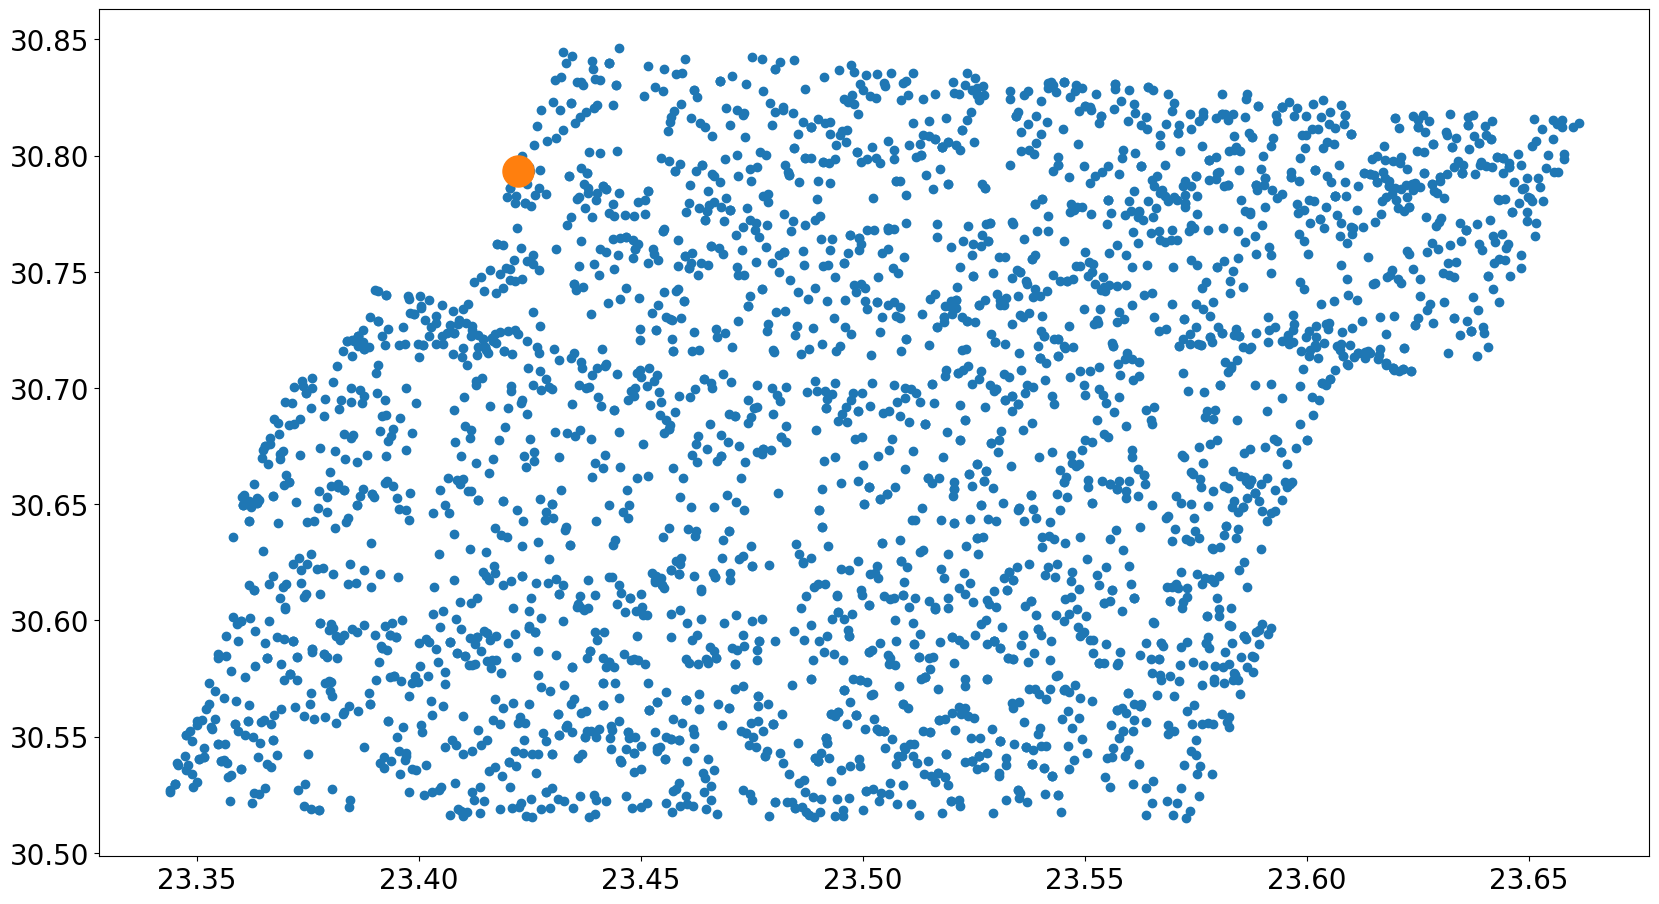

In [100]:
import pandas as pd

cepheid = pd.read_csv("m33_matched_spectra.csv")

ra_match = np.asarray(cepheid['Photometry_RA'])
dec_match = np.asarray(cepheid['Photometry_DEC'])

ra_table = data['RA_DEG']
dec_table = data['DEC_DEG']

plt.scatter(ra_table, dec_table)
plt.scatter(ra_match[0], dec_match[0], s=500)


In [101]:
print(ra_match)
print(np.asarray(ra_table))

[23.42229167 23.451625   23.418875   23.39766667 23.46095833 23.34583333
 23.55583333 23.47258333 23.38170833 23.41154167 23.52458333 23.53775
 23.36666667 23.44379167 23.358625   23.495125   23.390375   23.64983333]
[23.56497176 23.5778105  23.5675324  ...         nan         nan
         nan]


In [102]:
from astropy.coordinates import SkyCoord, angular_separation
import astropy.units as u

match_idx = np.full(len(ra_match)-1, np.nan)

for star in range(1, len(ra_match)):
    dist = angular_separation(ra_match[star]*u.deg, dec_match[star]*u.deg, np.asarray(ra_table)*u.deg, np.asarray(dec_table)*u.deg).to(u.arcsecond).value
    
    ichoose = np.where(dist <=0.2)[0]
    
    print(ichoose)
    if len(ichoose) >= 1:
        
        match_idx[star-1] = int(ichoose[0])
        
    

match_idx = match_idx.astype(int)
print(match_idx)


[2147]
[1646]
[1691]
[2446]
[2693]
[334]
[2640]
[826]
[612]
[1375]
[ 566 4886]
[165]
[1610]
[ 138 2682]
[866]
[2673]
[3462]
[2147 1646 1691 2446 2693  334 2640  826  612 1375  566  165 1610  138
  866 2673 3462]


In [103]:
print(wavln.shape)

(4919, 10770)


In [104]:
m33_ceph_spec = QTable()

m33_ceph_spec['Cepheid_RA'] = cepheid['Cepheid_RA'][1:]
m33_ceph_spec['Cepheid_DEC'] = cepheid['Cepheid_DEC'][1:]
m33_ceph_spec['Photometry_RA'] = cepheid['Photometry_RA'][1:]
m33_ceph_spec['Photometry_DEC'] = cepheid['Photometry_DEC'][1:]
m33_ceph_spec['F814W_Mag'] = cepheid['F814W_Mag'][1:]
m33_ceph_spec['F475W_Mag'] = cepheid['F475W_Mag'][1:]
m33_ceph_spec['F475W_minus_F814W'] = cepheid['F475W_minus_F814W'][1:]
m33_ceph_spec['wavelength'] = wavln[match_idx,:]
m33_ceph_spec['flux'] = flux[match_idx,:]
m33_ceph_spec['ivar'] = ivar[match_idx,:]

print(m33_ceph_spec)

    Cepheid_RA        Cepheid_DEC     ...    flux       ivar   
------------------ ------------------ ... ---------- ----------
 23.45165101417949 30.838640757073566 ... nan .. nan 0.0 .. 0.0
 23.41893101417949  30.76167075707357 ... nan .. nan 0.0 .. 0.0
23.397681014179486 30.738310757073567 ... nan .. nan 0.0 .. 0.0
23.461001014179487  30.78735075707357 ... nan .. nan 0.0 .. 0.0
23.345841014179488 30.537860757073567 ... nan .. nan 0.0 .. 0.0
23.555851014179485  30.55489075707357 ... nan .. nan 0.0 .. 0.0
 23.47257101417949  30.55233075707356 ... nan .. nan 0.0 .. 0.0
               ...                ... ...        ...        ...
 23.53777101417949 30.608200757073565 ... nan .. nan 0.0 .. 0.0
23.366671014179488 30.537000757073564 ... nan .. nan 0.0 .. 0.0
 23.44379101417949 30.779120757073567 ... nan .. nan 0.0 .. 0.0
 23.35862101417949 30.555520757073563 ... nan .. nan 0.0 .. 0.0
23.495091014179486 30.622130757073563 ... nan .. nan 0.0 .. 0.0
23.390441014179487  30.57457075707357 ..

(-500.0, 1500.0)

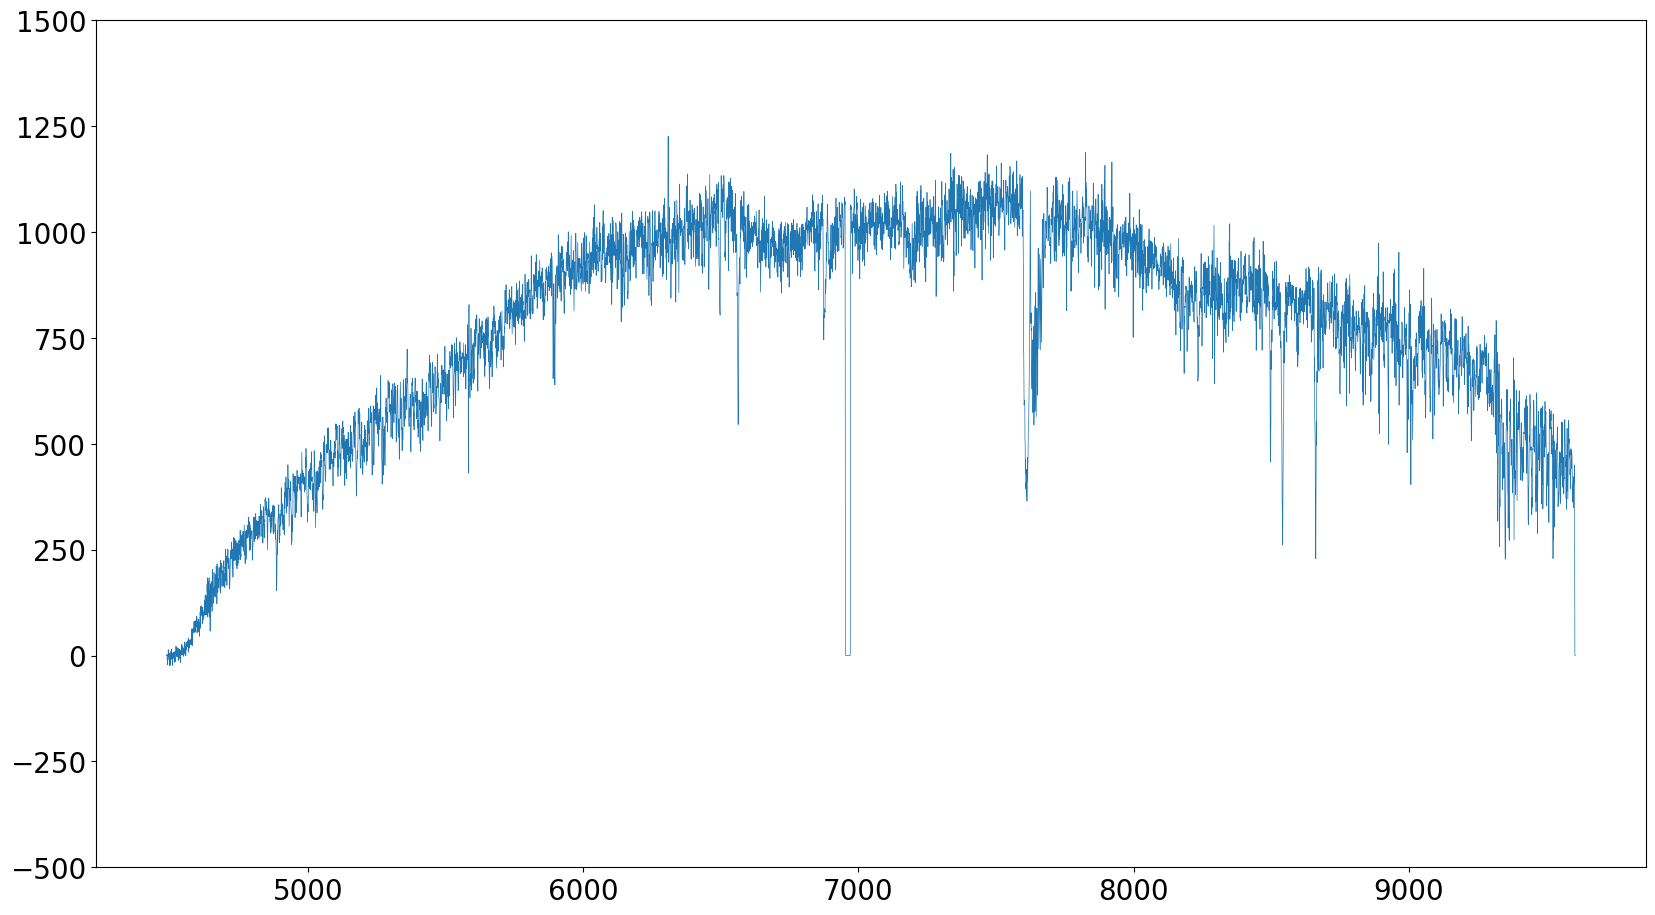

In [114]:
plt.plot(wavln[match_idx[3], :], flux[match_idx[3], :], lw=0.5)
plt.ylim(-500,1500)

In [105]:
m33_ceph_spec.write("m33_ceph_spec.fits")

In [6]:
wcn_idx = np.load("M33_wcnbool.npy")
cst_idx = np.load("M33_cstbool.npy")
print(wcn_idx[1550])

False


In [7]:
f275w = data["F275W"]
f336w = data["F336W"]
f475w = data['F475W']
f814w = data["F814W"]
f110w = data["F110W"]
f160w = data["F160W"]
ra = data['RA_DEG']
dec = data['DEC_DEG']
zquality = data['ZQUAL']

In [8]:
count = 0
keep = []

for i in range(len(zquality)):
    z = zquality[i]
    if z == 1 or z >2:
        count +=1
        keep.append(i)
print(count)

2683


In [9]:
ichoose1 = np.where((f814w==0.0))[0]
ichoose2 = np.where((f814w > 90.))[0]
ichoose3 = np.where((f814w < -90.))[0]
ichoose4 = np.where((np.isnan(f814w)==True))[0]

print(len(f814w))
print(len(f814w) - (len(ichoose1)+len(ichoose2)+len(ichoose3)+len(ichoose4)))

4919
3113


In [10]:
ichoose1 = np.where((f475w==0.0))[0]
ichoose2 = np.where((f475w > 90.))[0]
ichoose3 = np.where((f475w < -90.))[0]
ichoose4 = np.where((np.isnan(f475w)==True))[0]

print(len(f475w))
print(len(f475w) - (len(ichoose1)+len(ichoose2)+len(ichoose3)+len(ichoose4)))

4919
3113


In [11]:
ichoose1 = np.where((f336w==0.0))[0]
ichoose2 = np.where((f336w > 90.))[0]
ichoose3 = np.where((f336w < -90.))[0]
ichoose4 = np.where((np.isnan(f336w)==True))[0]

print(len(f336w))
print(len(f336w) - (len(ichoose1)+len(ichoose2)+len(ichoose3)+len(ichoose4)))

4919
1797


In [12]:
f275w = f275w[keep]
f336w = f336w[keep]
f475w = f475w[keep]
f814w = f814w[keep]
f110w = f110w[keep]
f160w = f160w[keep]

wcn_idx = wcn_idx[keep]
cst_idx = cst_idx[keep]

ra = ra[keep]
dec = dec[keep]

wavln = wavln[keep, :]
flux = flux[keep, :]
ivar = ivar[keep, :]

In [13]:
print(len(f160w))

2683


In [14]:
Wnm = np.where(wcn_idx==True)[0]
allcarbon = np.where(cst_idx==True)[0]

wcnkeep = [0, 5,9,11,18,20,21,22,23,24,25,26,30,34,35,36,37,38,39,40,42,60,63,64,65,66,67,68,69,71,72,73,75,76,
          77,78,80,81,82,83,85,86,87,88,89,90,108,115,116,125,126,127,128,130,131,132,134,135,136,137,138,139,
          141,142,143,144,145,148,149,150,151,152,153,154,156,157,161,162,164,166,167,169,173,175,177,178,186,
          187,189,192,194,197,200,203,204,205,206,208,210,211,212,213,215,217,218,220,226,227,229,230,232,236,
          247,250,253,275,278,287,289,292,293,297,299,300,318,319,320,322,330,331,332,335,369,380,382,384,386,
          387,413,416,]

cstkeep = [0,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24,27,28,29,30,31,32,33,34,35,36,38,53]

Wnm = Wnm[wcnkeep]
allcarbon=allcarbon[cstkeep]

wcn_idx = np.full(len(f160w), False)
cst_idx = np.full(len(f160w), False)

wcn_idx[Wnm] = True
cst_idx[allcarbon] = True


In [15]:
print(wcn_idx)
ichoose = np.where(wcn_idx==True)[0]
print(len(ichoose))

[False False False ... False False False]
140


In [16]:
'''fig, axs = plt.subplots(nrows=10, ncols=3, figsize=(35,50), sharey=True)

start = 30
wav_range = np.where((wavln[0,:]>6500)&(wavln[0,:]<9000))[0]
wav_range2 = np.where((wavln[0,:]>7600)&(wavln[0,:]<8300))[0]
for j in range(0,3):
    k=0
    for i in range(start, start+10):
        ax = axs[k,j]
        
        x = wavln[ichoose[i], :]
        y = flux[ichoose[i], :]
        
        ax.plot(x, y/np.nanmedian(y), lw=1, c='k')
        ax.tick_params(axis='both', which='both', labelsize=20)
        
        ax.set_ylim(0,2.5)
        ax.set_xlim(6500,9000)
        ymin, ymax = ax.get_ylim()
        
        ax.text(6600, ymin+0.85*(ymax-ymin), 'WCN #: '+str(i), backgroundcolor='lightgrey', fontsize=30)
        k+=1
    start+=10
    
fig.tight_layout()'''

"fig, axs = plt.subplots(nrows=10, ncols=3, figsize=(35,50), sharey=True)\n\nstart = 30\nwav_range = np.where((wavln[0,:]>6500)&(wavln[0,:]<9000))[0]\nwav_range2 = np.where((wavln[0,:]>7600)&(wavln[0,:]<8300))[0]\nfor j in range(0,3):\n    k=0\n    for i in range(start, start+10):\n        ax = axs[k,j]\n        \n        x = wavln[ichoose[i], :]\n        y = flux[ichoose[i], :]\n        \n        ax.plot(x, y/np.nanmedian(y), lw=1, c='k')\n        ax.tick_params(axis='both', which='both', labelsize=20)\n        \n        ax.set_ylim(0,2.5)\n        ax.set_xlim(6500,9000)\n        ymin, ymax = ax.get_ylim()\n        \n        ax.text(6600, ymin+0.85*(ymax-ymin), 'WCN #: '+str(i), backgroundcolor='lightgrey', fontsize=30)\n        k+=1\n    start+=10\n    \nfig.tight_layout()"

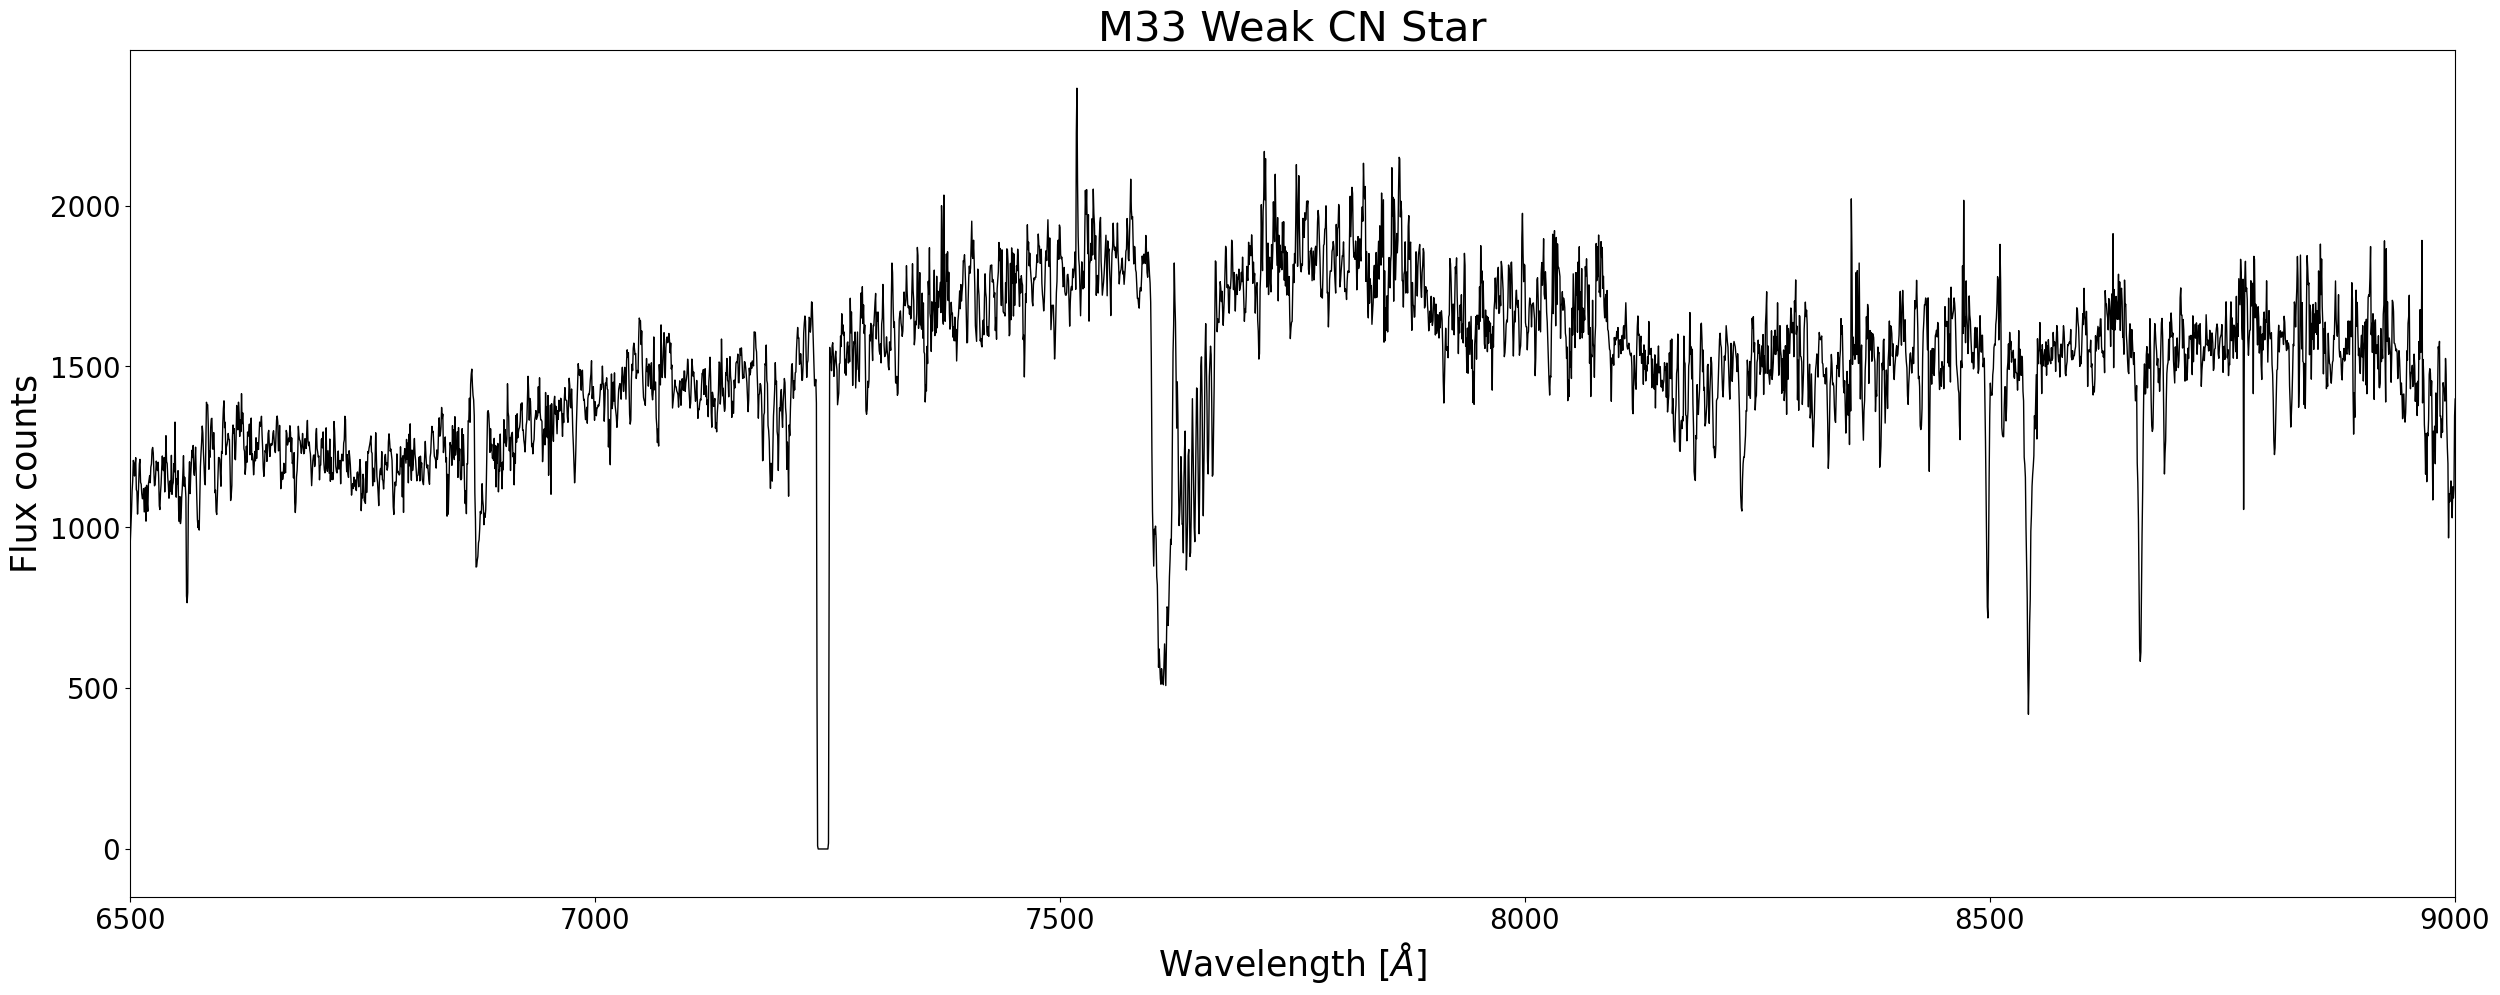

In [17]:
num =21
x = wavln[ichoose[num], :]
y = flux[ichoose[num], :]
plt.rcParams['figure.figsize'] = 30,11
plt.plot(x, y, lw=1, c='k')
plt.xlim(6500,9000)
plt.title("M33 Weak CN Star", size = 30)
plt.ylabel("Flux counts", size = 25)
plt.xlabel("Wavelength [$\AA$]", size = 25)
plt.tick_params(axis='both', which='both', labelsize=20)

plt.show()

In [18]:
#defines variables that will be used for clipping spectra to the right wavelength window
#goal: isolate the 'W' shaped feature shared by carbon and weak CN stars
lowerThresh = 5840         #represents 7796.0 angstroms in data["LBIN"]
upperThresh = 6550         #represents 8257.5 angstroms in data["LBIN"]
middleThresh = 6184        #represents 8019.6 angstroms in data["LBIN"]; point between the two 'U's

fullSpec_low = 0
fullSpec_high = len(wavln[0,:])

In [19]:
#performing a NaN cut on the stars to eliminate any whose spectra are more than 10% NaNs on the 'W' range
NANvalidstars_list = np.arange(0, len(wavln[:,0]), 1)
NANvalidstars_list = NANvalidstars_list.tolist()
for star in range(0, len(wavln[:,0])):
    NANcount = 0
    for f in flux[star,lowerThresh:upperThresh]:
        if np.isnan(f):
            NANcount += 1
    if NANcount > 0.1*len(flux[:, lowerThresh:upperThresh]):
        NANvalidstars_list.remove(star)
NANvalidstars = np.array(NANvalidstars_list)

#metadata: showing how many stars were cut out of the data due to the NaN limits
print(str(len(wavln[:,0])) + ' stars became ' + str(len(NANvalidstars)) + ' after the NaN cut.')

2683 stars became 2673 after the NaN cut.


In [20]:
np.save("NANvalid.npy", NANvalidstars)

In [20]:
f275w = f275w[NANvalidstars]
f336w = f336w[NANvalidstars]
f475w = f475w[NANvalidstars]
f814w = f814w[NANvalidstars]
f110w = f110w[NANvalidstars]
f160w = f160w[NANvalidstars]

wcn_idx = wcn_idx[NANvalidstars]
cst_idx = cst_idx[NANvalidstars]

ra = ra[NANvalidstars]
dec = dec[NANvalidstars]

#np.save("M33_wcnidx.npy", wcn_idx)
#np.save("M33_cstidx.npy", cst_idx)

Wnm = np.where((wcn_idx == True))[0]
print(len(Wnm))
allcarbon = np.where((cst_idx == True))[0]

others = np.arange(0, len(wavln[0,:]), 1)
delete = np.append(allcarbon, Wnm)
others = np.delete(others, delete)

wavln = wavln[NANvalidstars,:]
flux = flux[NANvalidstars,:]
ivar = ivar[NANvalidstars,:]

140


In [21]:
len(allcarbon)

34

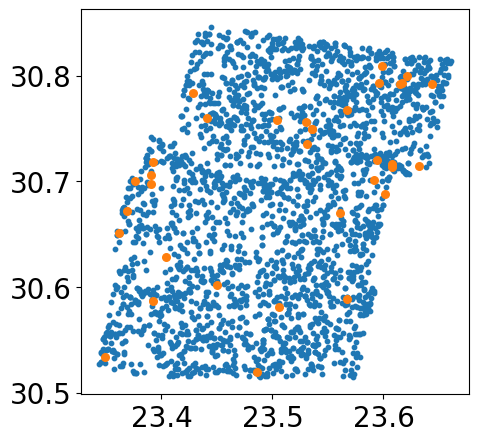

In [22]:
plt.figure(figsize=(5,5))
plt.scatter(ra, dec, s=10)
plt.scatter(ra[allcarbon], dec[allcarbon], s=30)

In [47]:
from astropy.table import QTable

cst_table = QTable()
cst_table['wavelength'] = wavln[allcarbon,:]
cst_table['flux'] = flux[allcarbon, :]
cst_table['ivar'] = ivar[allcarbon, :]
cst_table['ra'] = ra[allcarbon]
cst_table['dec'] = dec[allcarbon]
cst_table['f275w'] = f275w[allcarbon]
cst_table['f336w'] = f336w[allcarbon]
cst_table['f475w'] = f475w[allcarbon]
cst_table['f814w'] = f814w[allcarbon]
cst_table['f110w'] = f110w[allcarbon]
cst_table['f160w'] = f160w[allcarbon]

cst_table.write("M33_Cstars.fits")



In [ ]:
cst_table = QTable()
cst_table['wavelength'] = wavln[allcarbon,:]
cst_table['flux'] = flux[allcarbon, :]
cst_table['ivar'] = ivar[allcarbon, :]

cst_table.write("M33_cst_spectra.fits", overwrite=True)



In [23]:
print(len(allcarbon))

34


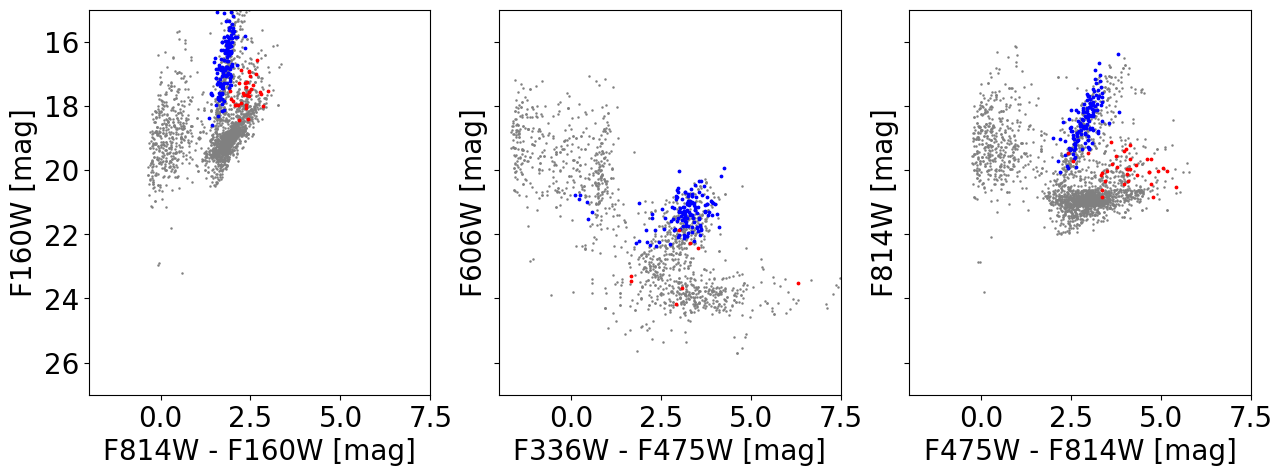

In [23]:
index_o = np.arange(0, len(wcn_idx), 1)
delete2 = np.append(allcarbon, Wnm)
index_o = np.delete(index_o, delete2)

fig,axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5), sharey=True)

ax = axs[0]

ax.scatter(f814w[index_o]-f160w[index_o], f160w[index_o], s=0.6, c='grey', label="All")
ax.scatter(f814w[Wnm]-f160w[Wnm], f160w[Wnm], c='blue',s=3, label='Weak-CN')
ax.scatter(f814w[allcarbon]-f160w[allcarbon], f160w[allcarbon], s=3, c='red', label="Carbon Stars")
ax.set_xlabel("F814W - F160W [mag]")
ax.set_ylabel("F160W [mag]")
ax.set_xlim(-2,7.5)
#ax.legend()

ax = axs[1]

ax.scatter(f336w[index_o]-f475w[index_o], f475w[index_o], s=0.6, c='grey', label="All")
ax.scatter(f336w[Wnm]-f475w[Wnm], f475w[Wnm], c='blue',s=3, label='Weak-CN')
ax.scatter(f336w[allcarbon]-f475w[allcarbon], f475w[allcarbon], s=3, c='red', label="Carbon Stars")
ax.set_xlabel("F336W - F475W [mag]")
ax.set_ylabel("F606W [mag]")
ax.set_xlim(-2,7.5)

ax = axs[2]

ax.scatter(f475w[index_o]-f814w[index_o], f814w[index_o], s=0.6, c='grey', label="All")
ax.scatter(f475w[Wnm]-f814w[Wnm], f814w[Wnm], c='blue',s=3, label='Weak-CN')
ax.scatter(f475w[allcarbon]-f814w[allcarbon], f814w[allcarbon], s=3, c='red', label="Carbon Stars")
ax.set_xlabel("F475W - F814W [mag]")
ax.set_ylabel("F814W [mag]")
ax.set_xlim(-2,7.5)

for ax in axs:
    ax.set_ylim(27,15)

In [24]:
#defines a function that will slice any spectrum to desired wavelengths
def sliceSpec(star, lower = lowerThresh, upper = upperThresh):
    '''
    star: the index of a particular star (with corresponding spectrum) in SPLASH
    lower: the lower boundary of the slice, in terms of wavelength
    upper: the upper boundary of the slice, in terms of wavelength
    
    lower and upper will default to the lowerThresh and upperThresh values defined above, respectively
    
    Returns newWv, a Numpy array containing every wavelength value between lower and upper for which data exists for a certain star 
    Also returns newFlux, a Numpy array containing the flux values that (for a certain star) correspond to each of the wavelength values in newSpec
    Also returns newIvar, a Numpy array containing the ivar values that (for a certain star) corresopnd to each of the wavelength values in newSpec
    '''
    newWv = wavln[star][lower:upper]
    newFlux = flux[star][lower:upper]
    newIvar = ivar[star][lower:upper]
    return newWv, newFlux, newIvar

In [25]:
def normspec(star, lower = lowerThresh, upper = upperThresh):
    wvSlice, fluxSlice, ivarSlice = sliceSpec(star, lower, upper)
    
    
    nan1 = fluxSlice==0
    fluxSlice[nan1] = np.nan
    ivarSlice[nan1] = 0
    
    nan2 = ivarSlice ==0
    fluxSlice[nan2] = np.nan
    ivarSlice[nan2] =0
    
    wvSlice_list = wvSlice.tolist()
    fluxSlice_list = fluxSlice.tolist()
    ivarSlice_list = ivarSlice.tolist()
    
    #creating a version of the spectrum without any NaNs for performing median/standard deviation calculations
    #if the spectrum is all NaNs on the range specified in the function call, will return an error
    #if the spectrum is all 0s on the range specified in the function call, will replace the 0s with NaNs and returm am error
    newFluxSlice = []
    for wv in range(len(fluxSlice_list)):
        if np.isnan(ivarSlice_list[wv]) or np.isnan(fluxSlice_list[wv]):
            ivarSlice_list[wv] = 0
        else: #add to "non-zero, non-NaN" data
            newFluxSlice.append(fluxSlice_list[wv])
    if newFluxSlice == []:
        print("NormalizationError: The spectrum for star " + str(star) + " contains only NaN values on the specified range. It cannot be normalized.")
        return np.array(wvSlice), np.array(fluxSlice_list), np.array(ivarSlice_list), False
    
    medianFlux = st.median(newFluxSlice)
    spec_mean = st.mean(newFluxSlice)
    spec_stdev = st.stdev(newFluxSlice)
    upperLim = spec_mean + 5*spec_stdev #limits calculated to clip out values around nan
    lowerLim = spec_mean - 5*spec_stdev
    
    #replaces with np.nan values that are within 5 pixels of a nan value and outside of 5 standard deviations from the mean flux 
    #accomodates for nan values being located on the edges of the spectrum (in positions where 5 pixels out in either direction would be out of range)
    nanIndices = []
    for index in range(len(fluxSlice_list)):
        if np.isnan(fluxSlice_list[index]): 
            if 5 < index < len(wvSlice_list) - 5:
                for i in range(index-5,index+5):
                    if lowerLim > fluxSlice_list[i] or upperLim < fluxSlice_list[i]:
                        fluxSlice_list[i] = np.nan
            elif 5 > index:
                for i in range(0,index+5):
                    if lowerLim > fluxSlice_list[i] or upperLim < fluxSlice_list[i]:
                        fluxSlice_list[i] = np.nan
            elif index > len(wvSlice_list) - 5:
                for i in range(index-5, len(wvSlice)): #this should go upto len(specSlice)-1 due to 0-indexing
                    if lowerLim > fluxSlice_list[i] or upperLim < fluxSlice_list[i]:
                        fluxSlice_list[i] = np.nan
    
    #at each pixel, normalizes the star's spectrum and modifies the corresponding ivar value
    normedFlux = fluxSlice/medianFlux
    normedIvar = ivarSlice*medianFlux**2
    
    #converts the final products back to arrays for easy manipulation later in the code
    normedFlux_np = np.array(normedFlux)
    normedIvar_np = np.array(normedIvar)
    wvSlice_np = np.array(wvSlice)
    
    return wvSlice_np, normedFlux_np, normedIvar_np, True

In [26]:
#creates splashSpecs_dict, a dictionary of the normalized spectra for every valid star in SPLASH, and splashIvars_dict, a dictionary of the normalized ivar values for those same stars
#keys are the indices of stars, paired values are arrays representing the flux/ivar values of those stars at every wavelength in the range identified
#note that NormalizationError messages may appear if stars that cannot be normalized; in these cases, star index keys are paired with arrays of NaN values in splashSpecs_dict and arrays of 0s in splashIvars_dict (because ivar = 0 for every NaN)
splashSpecs_dict, splashIvars_dict, splashSuccess_dict = {}, {}, {}

#creates a list of stars with high median ivars to later test against their brightnesses
highIvarStars = []

#create lists of median ivars for every star (without including NaN or 0 medians)
#also sets up dictionaries of star:medianIvar for later use in ivar trimming, etc
#note that if a star's spectrum could not be normalized, it will be excluded from these dictionaries (rather than paired with NaNs as was done earlier)
wNm_ivarMeds, carbon_ivarMeds, kphOthers_ivarMeds = [], [], []
wNm_ivarMeds_dict, carbon_ivarMeds_dict, kphOthers_ivarMeds_dict = {}, {}, {}

IVAR_LIMIT = 1000 #an arbitrary constant that acts as the defining limit for what counts as a high-ivar star

for star in tqdm(range(0, len(wavln[:,0]))):
    #the following lines are done for all stars, as a part of the base dictionary creation
    spSlice, normSp, normIv, success = normspec(star = star)
    splashSpecs_dict[star], splashIvars_dict[star], splashSuccess_dict[star] = normSp, normIv, success
    
    #now, based on star type (wNm, carbon, other, highIvar), normIv is added to its corresponding list to be used in subsequent ivar trimming and graphs
    if success: #if the star could not be normalized, then won't be needed in trimming/statistical analyses
        if star in Wnm:
            med = np.nanmedian(normIv)
            if med != 0:
                wNm_ivarMeds.append(med); wNm_ivarMeds_dict[star] = med
        if star in allcarbon:
            med = np.nanmedian(normIv)
            if med != 0:
                carbon_ivarMeds.append(med); carbon_ivarMeds_dict[star] = med
        if np.nanmedian(normIv) > IVAR_LIMIT:
            highIvarStars.append(star)
        if star in others:
            med = np.nanmedian(normIv)
            if med != 0:
                kphOthers_ivarMeds.append(med); kphOthers_ivarMeds_dict[star] = med

 56%|█████████████████████▏                | 1489/2673 [00:09<00:07, 166.76it/s]

NormalizationError: The spectrum for star 1459 contains only NaN values on the specified range. It cannot be normalized.


 86%|████████████████████████████████▌     | 2287/2673 [00:14<00:02, 161.47it/s]

NormalizationError: The spectrum for star 2261 contains only NaN values on the specified range. It cannot be normalized.


100%|██████████████████████████████████████| 2673/2673 [00:16<00:00, 162.25it/s]


In [27]:
#defines a function that clips out outlier data points in a set of spectra 
#outliers are defined as points that lie outside of a certain number of standard deviations away from the median flux value at each wavelength
def sigmaClip(spectra, ivars, nsigma = 3.5):
    '''
    spectra: a list of the spectra of each star that is being clipped
    ivars: a list of the sets of ivars for each star that is being coadded
    nsigma: an integer or float representing the number of standard deviations away from the median to be used in clipping
    
    nsigma will default to 3.5 unless otherwise specified
    spectra and ivar values must be normalized and corresponding for best results
    
    Returns spectra, a list of the spectra of each star in terms of flux
    Also returns ivars, a list of the set of ivars of each star with values corresponding to the invalid values in spectra (those that lie more than nsigma standard deviations away from the median) replaced by 0s
    '''
    sortedSpecList = []
    for value in range(len(spectra[1])): #note that the use of spectra[1] is arbitrary as all of the lists in spectra have the same length
        listToAdd = []
        for spectrum in range(len(spectra)):
            if not np.isnan(spectra[spectrum][value]):
                listToAdd.append(spectra[spectrum][value])
        sortedSpecList.append(listToAdd)
    medians = []
    for eachlist in range(len(sortedSpecList)):
        if len(sortedSpecList[eachlist]) != 0:
            medians.append(st.median(sortedSpecList[eachlist]))
        else: 
            medians.append(np.nan)
    for spectrum in range(len(spectra)):
        for flux in range(len(spectra[1])): #see above comment
            if np.isnan(medians[flux]):
                continue
            elif ivars[spectrum][flux] != 0 and not np.isnan(spectra[spectrum][flux]):
                testFlux = ((spectra[spectrum][flux] - medians[flux])**2)*ivars[spectrum][flux] 
                if testFlux > nsigma**2:
                    spectra[spectrum][flux] = np.nan
                    ivars[spectrum][flux] = 0          
    return spectra, ivars

In [28]:
#defines a function that will coadd normalized spectra based on provided lists of spectra and ivar weights
def coadd(spectra, ivars, lower = lowerThresh, upper = upperThresh):
    '''
    spectra: a list of the spectra of each star that is being coadded
    ivars: a list of the sets of ivars for each star that is being coadded
    lower: the lower boundary of the range the spectrum have been normalized on, in terms of wavelength
    upper: the upper boundary of the range the spectrum have been normalized on, in terms of wavelength
    
    lower and upper will default to the lowerThresh and upperThresh values defined above, respectively
    spectra and ivar values must be normalized and corresponding for best results
    
    Returns wvValues_np, a Numpy array containing every wavelength value for which spectral data exists between lower and upper
    Also returns coaddedFlux_np, a Numpy array containing the flux values of the coadded spectrum corresponding to each wavelength in wvValues_np 
    Also returns coaddedIvar_np, a Numpy array containing the ivar values of the coadded spectrum corresponding to each wavelength in  wvValues_np
    '''
    wvValues = wavln[0, lower:upper].tolist()
    coaddedFlux = []
    coaddedIvar = []
    for wv in range(len(wvValues)):
        fluxSum = 0
        ivarSum = 0
        for star in range(len(spectra)):
            if not np.isnan(spectra[star][wv]): 
                fluxSum += spectra[star][wv] * ivars[star][wv] #multiplying by ivar as a weight, as per formula
                ivarSum += ivars[star][wv]
        if ivarSum == 0:
            coaddedFlux.append(np.nan)
            coaddedIvar.append(0)
        else:
            newFlux = fluxSum/ivarSum #normalizing the weights, as per formula
            coaddedFlux.append(newFlux) #coaddedSpec now contains a coadded spectrum value at each LBIN value
            coaddedIvar.append(ivarSum) #coadded ivar is simply the sum of all ivars for a certain bin, across all stars (based on a mathematical proof)
    for flux in range(len(coaddedFlux)):
        if coaddedFlux[flux] == 0:
            coaddedFlux[flux] = np.nan
    coaddedFlux_np = np.asarray(coaddedFlux)
    wvValues_np = np.asarray(wvValues)
    coaddedIvar_np = np.asarray(coaddedIvar)
    return wvValues_np, coaddedFlux_np, coaddedIvar_np

In [29]:
def rms(spectra, coad, lower = lowerThresh, upper = upperThresh):
    
    wvValues = wavln[0, lower:upper].tolist()
    spectra = np.asarray(spectra)
    
    N = len(wvValues)
    rms_squared = np.zeros(shape=N)
    for wv in range(N):
        rms_squared[wv] = np.nansum((spectra[:,wv]-coad[wv])**2)
        
    rms = np.sqrt(rms_squared/(N-1))
    return rms

    '''
    def get_rms(starIndices, lower = lowerThresh, upper = upperThresh, nsigma = 3.5):
        #creating lists of normalized spectra and ivars for each star to be coadded
        spectra = []
        ivars = []
        for star in starIndices:
            if lower == lowerThresh and upper == upperThresh:
                #spectra.append(applyGauss(splashSpecs_dict[star],gauss=6).tolist())
                spectra.append(splashSpecs_dict[star].tolist())
                ivars.append(splashIvars_dict[star].tolist())
            else:
                starSpec, starIvar = normspec(star = star, lower = lower, upper = upper)[1:3]
                #starSpec = applyGauss(starSpec,gauss=6)
                spectra.append(starSpec.tolist())
                ivars.append(starIvar.tolist())
        print("Step 1 of 3 complete. Normalized spectra and inverse variances loaded.")

        #takes the original data and replaces with NaN values any data points that are greater than nsigma standard deviations from the median
        #the median is defined as the median flux at each wavelength when the flux values for every spectrum at that wavelength are considered
        spectra_new, ivars_new = sigmaClip(spectra, ivars, nsigma)
        print("Step 2 of 3 complete. Spectral and ivar data clipped to " + str(nsigma) + " sigmas.")

        rms_new = rms(spectra_new, lower, upper)

        return rms_new
    '''

In [30]:
#defines a function that creates a coadded template spectrum by combining several spectra normalized over a certain range
def getTempSpec(starIndices, lower = lowerThresh, upper = upperThresh, nsigma = 3.5):
    '''
    starIndices: an array or list of the indices of the stars to be coadded (which correspond to spectra in SPLASH)
    lower: the lower boundary of the range the spectrum will be normalized on, in terms of wavelength
    upper: the upper boundary of the range the spectrum will be normalized on, in terms of wavelength
    nsigma: a numerical value representing the number of standard deviations away from the flux medians that data for the coaddition will be trimmed to
    
    lower and upper will default to the lowerThresh and upperThresh values defined above, respectively
    nsigma will default to 3.5 unless another value is provided
    
    Returns coadd_wv, the set of all wavelength values for which data exists in the final coadded spectrum
    Also returns coadd_spec, the set of all flux values that correspond to the wavelength values in coadd_wv for the final coadded spectrum
    Also returns coadd_ivar, the number representing the ivar for every wavelength value on the final coadded spectrum
    Note that the final spectrum has been created from nsigma clipped data
    '''
    #creating lists of normalized spectra and ivars for each star to be coadded
    spectra = []
    ivars = []
    for star in starIndices:
        if lower == lowerThresh and upper == upperThresh:
            #spectra.append(applyGauss(splashSpecs_dict[star],gauss=6).tolist())
            spectra.append(splashSpecs_dict[star].tolist())
            ivars.append(splashIvars_dict[star].tolist())
        else:
            starSpec, starIvar = normspec(star = star, lower = lower, upper = upper)[1:3]
            #starSpec = applyGauss(starSpec,gauss=6)
            spectra.append(starSpec.tolist())
            ivars.append(starIvar.tolist())
    print("Step 1 of 3 complete. Normalized spectra and inverse variances loaded.")

    #takes the original data and replaces with NaN values any data points that are greater than nsigma standard deviations from the median
    #the median is defined as the median flux at each wavelength when the flux values for every spectrum at that wavelength are considered
    spectra_new, ivars_new = sigmaClip(spectra, ivars, nsigma)
    print("Step 2 of 3 complete. Spectral and ivar data clipped to " + str(nsigma) + " sigmas.")

    #performs the coaddition with the edited data from the last step
    coadd_wv, coadd_spec, coadd_ivar = coadd(spectra_new, ivars_new, lower, upper)
    print("Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.")
    
    rms_new = rms(spectra_new, coadd_spec, lower, upper)
    
    return coadd_wv, coadd_spec, coadd_ivar, rms_new

In [31]:
Ctemplate_wv, Ctemplate, Ctemplate_ivar, rms_C = getTempSpec(allcarbon)
Ctemplate_wv_full, Ctemplate_full, Ctemplate_ivar_full, rms_C_full = getTempSpec(allcarbon, lower = fullSpec_low, upper = fullSpec_high)
Wtemplate_wv, Wtemplate, Wtemplate_ivar,rms_W = getTempSpec(Wnm)
Wtemplate_wv_full, Wtemplate_full, Wtemplate_ivar_full,rms_W_full = getTempSpec(Wnm, lower = fullSpec_low, upper = fullSpec_high)

Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.


In [90]:
np.save("WCN_TemplateFull_M33.npy", Wtemplate_full)
np.save("CST_TemplateFull_M33.npy", Ctemplate_full)

In [21]:
xaxis_temp = wavln[0,:]
yaxis_temp = np.load("WCN_TemplateFull_M33.npy")
yaxis_temp2 = np.load("CST_TemplateFull_M33.npy")

template_table = QTable()

template_table['wavelength'] = xaxis_temp
template_table['wcn template'] = yaxis_temp
template_table['cst template'] = yaxis_temp2

template_table.write("M33_template_spectra.fits")

In [91]:
pwd

'/Users/douglasgrionfilho/Downloads/Raja/Raja/M33'

In [22]:
print(len(xaxis_temp))
print(len(yaxis_temp))

10770
10770


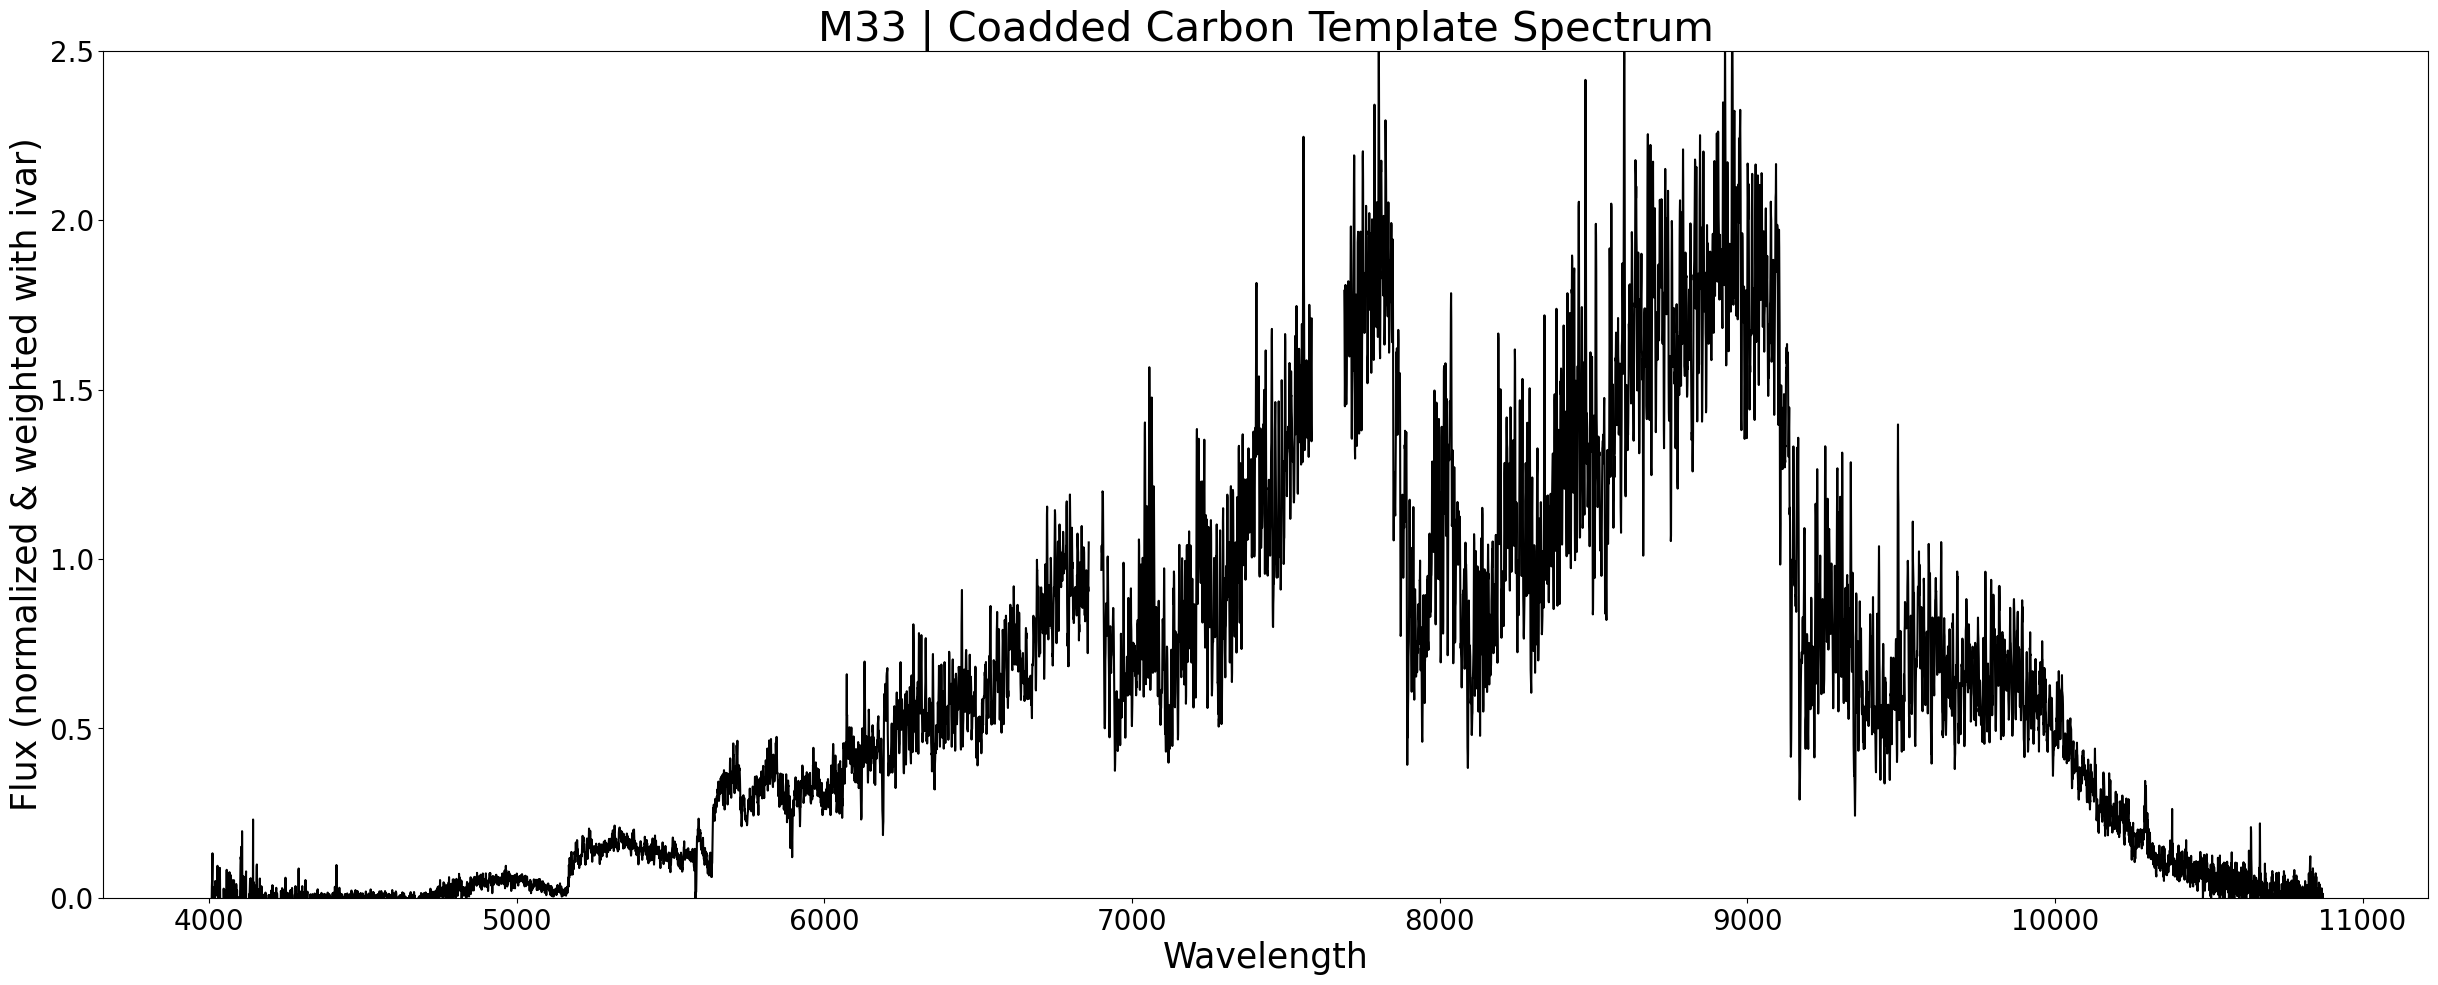

In [30]:
x = Ctemplate_wv_full
y = Ctemplate_full

ichoose = np.where((x>7585)&(x<7690))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((x>6860)&(x<6900))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((x>7796.0)&(x<8257.5))[0]

y = y/np.nanmedian(y[ichoose])

plt.rcParams['figure.figsize'] = 30,11
plt.plot(x, y, c='k')
plt.title("M33 | Coadded Carbon Template Spectrum", size = 30)
plt.ylabel("Flux (normalized & weighted with ivar)", size = 25)
plt.xlabel("Wavelength", size = 25)
plt.tick_params(axis='both', which='both', labelsize=20)
plt.ylim(0.,2.5)
plt.show()

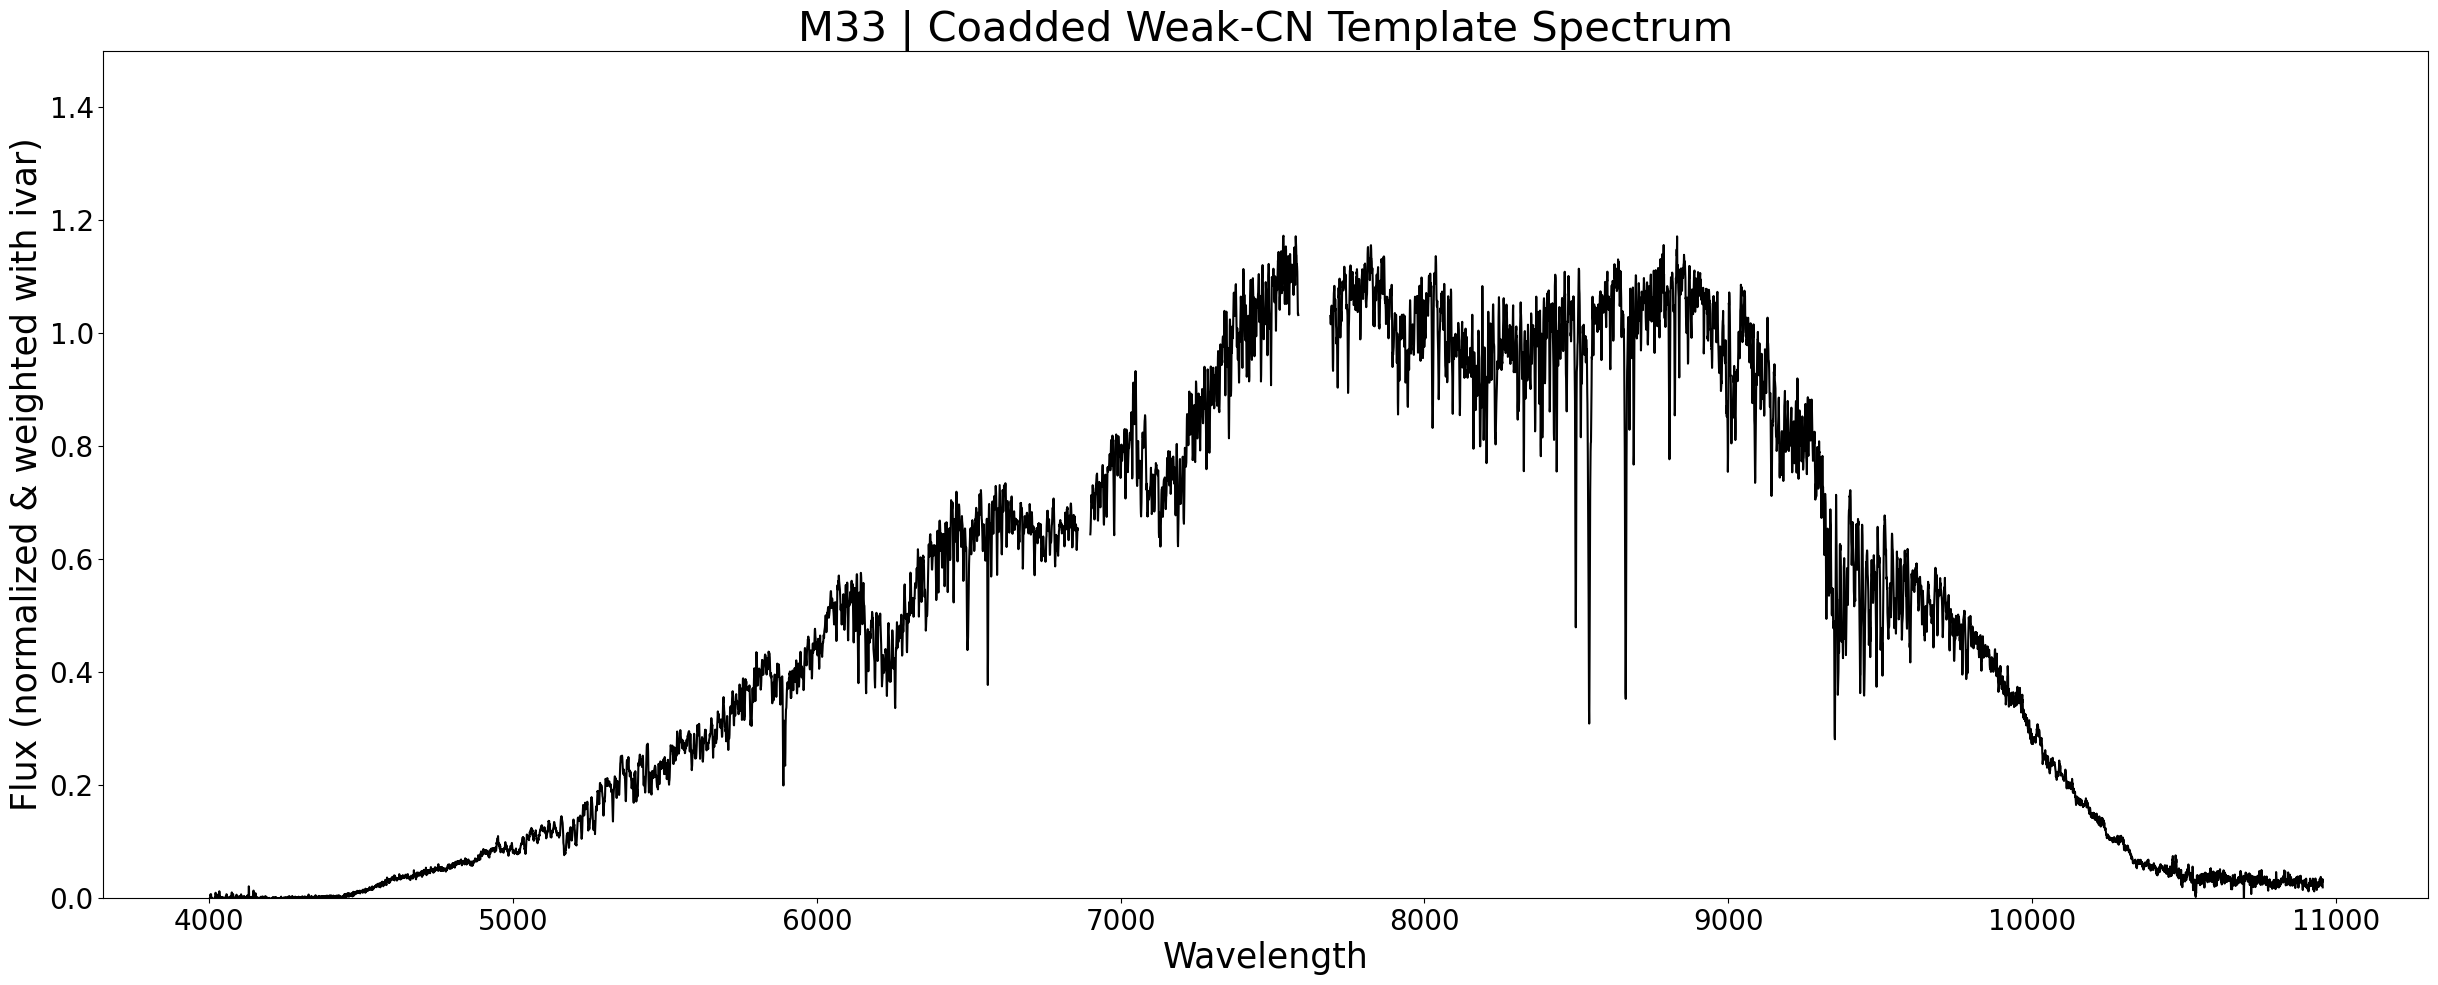

In [31]:
x = Wtemplate_wv_full
y = Wtemplate_full

ichoose = np.where((x>7585)&(x<7690))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((x>6860)&(x<6900))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((x>7796.0)&(x<8257.5))[0]

y = y/np.nanmedian(y[ichoose])

plt.rcParams['figure.figsize'] = 30,11
plt.plot(x, y, c='k')
plt.title("M33 | Coadded Weak-CN Template Spectrum", size = 30)
plt.ylabel("Flux (normalized & weighted with ivar)", size = 25)
plt.xlabel("Wavelength", size = 25)
plt.tick_params(axis='both', which='both', labelsize=20)
plt.ylim(0.,1.5)
plt.show()

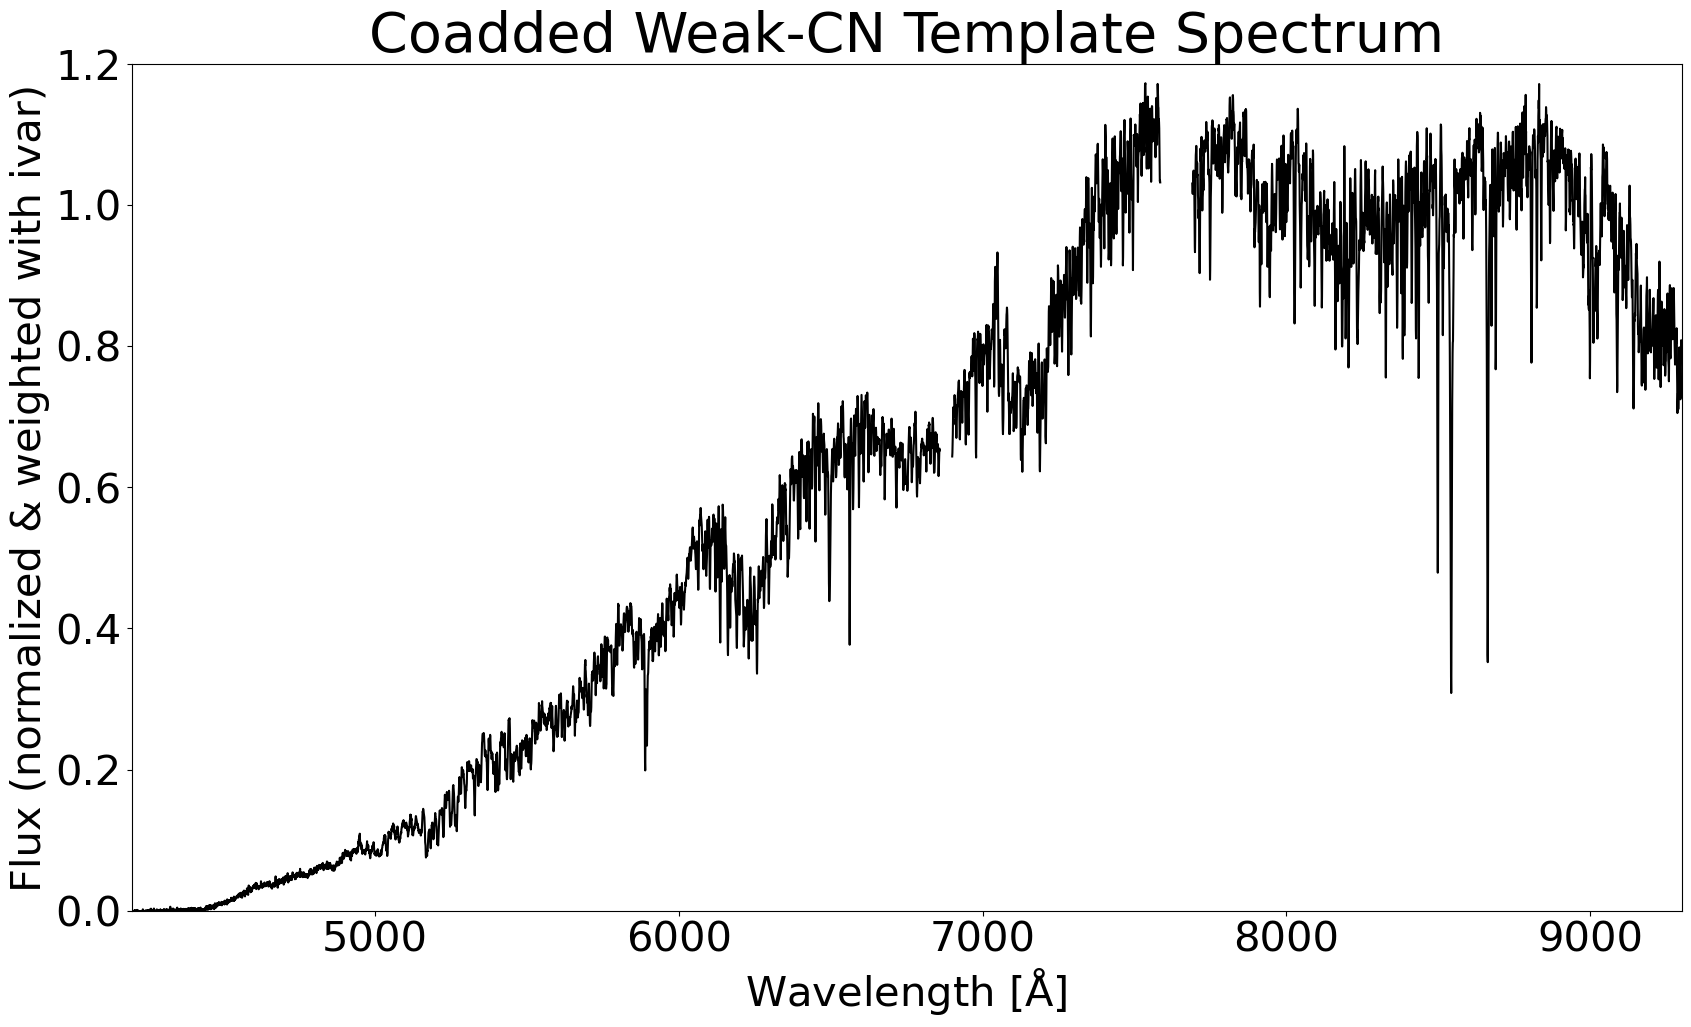

In [32]:
x = Wtemplate_wv_full
y = Wtemplate_full

ichoose = np.where((Wtemplate_wv_full>7585)&(Wtemplate_wv_full<7690))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((Wtemplate_wv_full>6860)&(Wtemplate_wv_full<6900))[0]
x[ichoose] = np.nan
y[ichoose] = np.nan

ichoose = np.where((Wtemplate_wv_full>7796.0)&(Wtemplate_wv_full<8257.5))[0]

y = y/np.nanmedian(y[ichoose])

plt.rcParams['figure.figsize'] = 20,11
plt.plot(x, y, c='k')
plt.title("Coadded Weak-CN Template Spectrum", size = 40)
plt.ylabel("Flux (normalized & weighted with ivar)", size = 30)
plt.xlabel("Wavelength $[\mathrm{\AA}]$", size = 30)
plt.tick_params(axis='both', which='both', labelsize=30)

#plt.axvline(7690, c='k', linewidth=2)

#plt.axvline(8490, c='k', linewidth=2)

#plt.axvline(8200, c='lightgray',ls='--', linewidth=2)
#plt.axvline(7800, c='lightgray',ls='--', linewidth=2)
plt.xlim(4200,9300)
plt.ylim(0.,1.2)
plt.show()

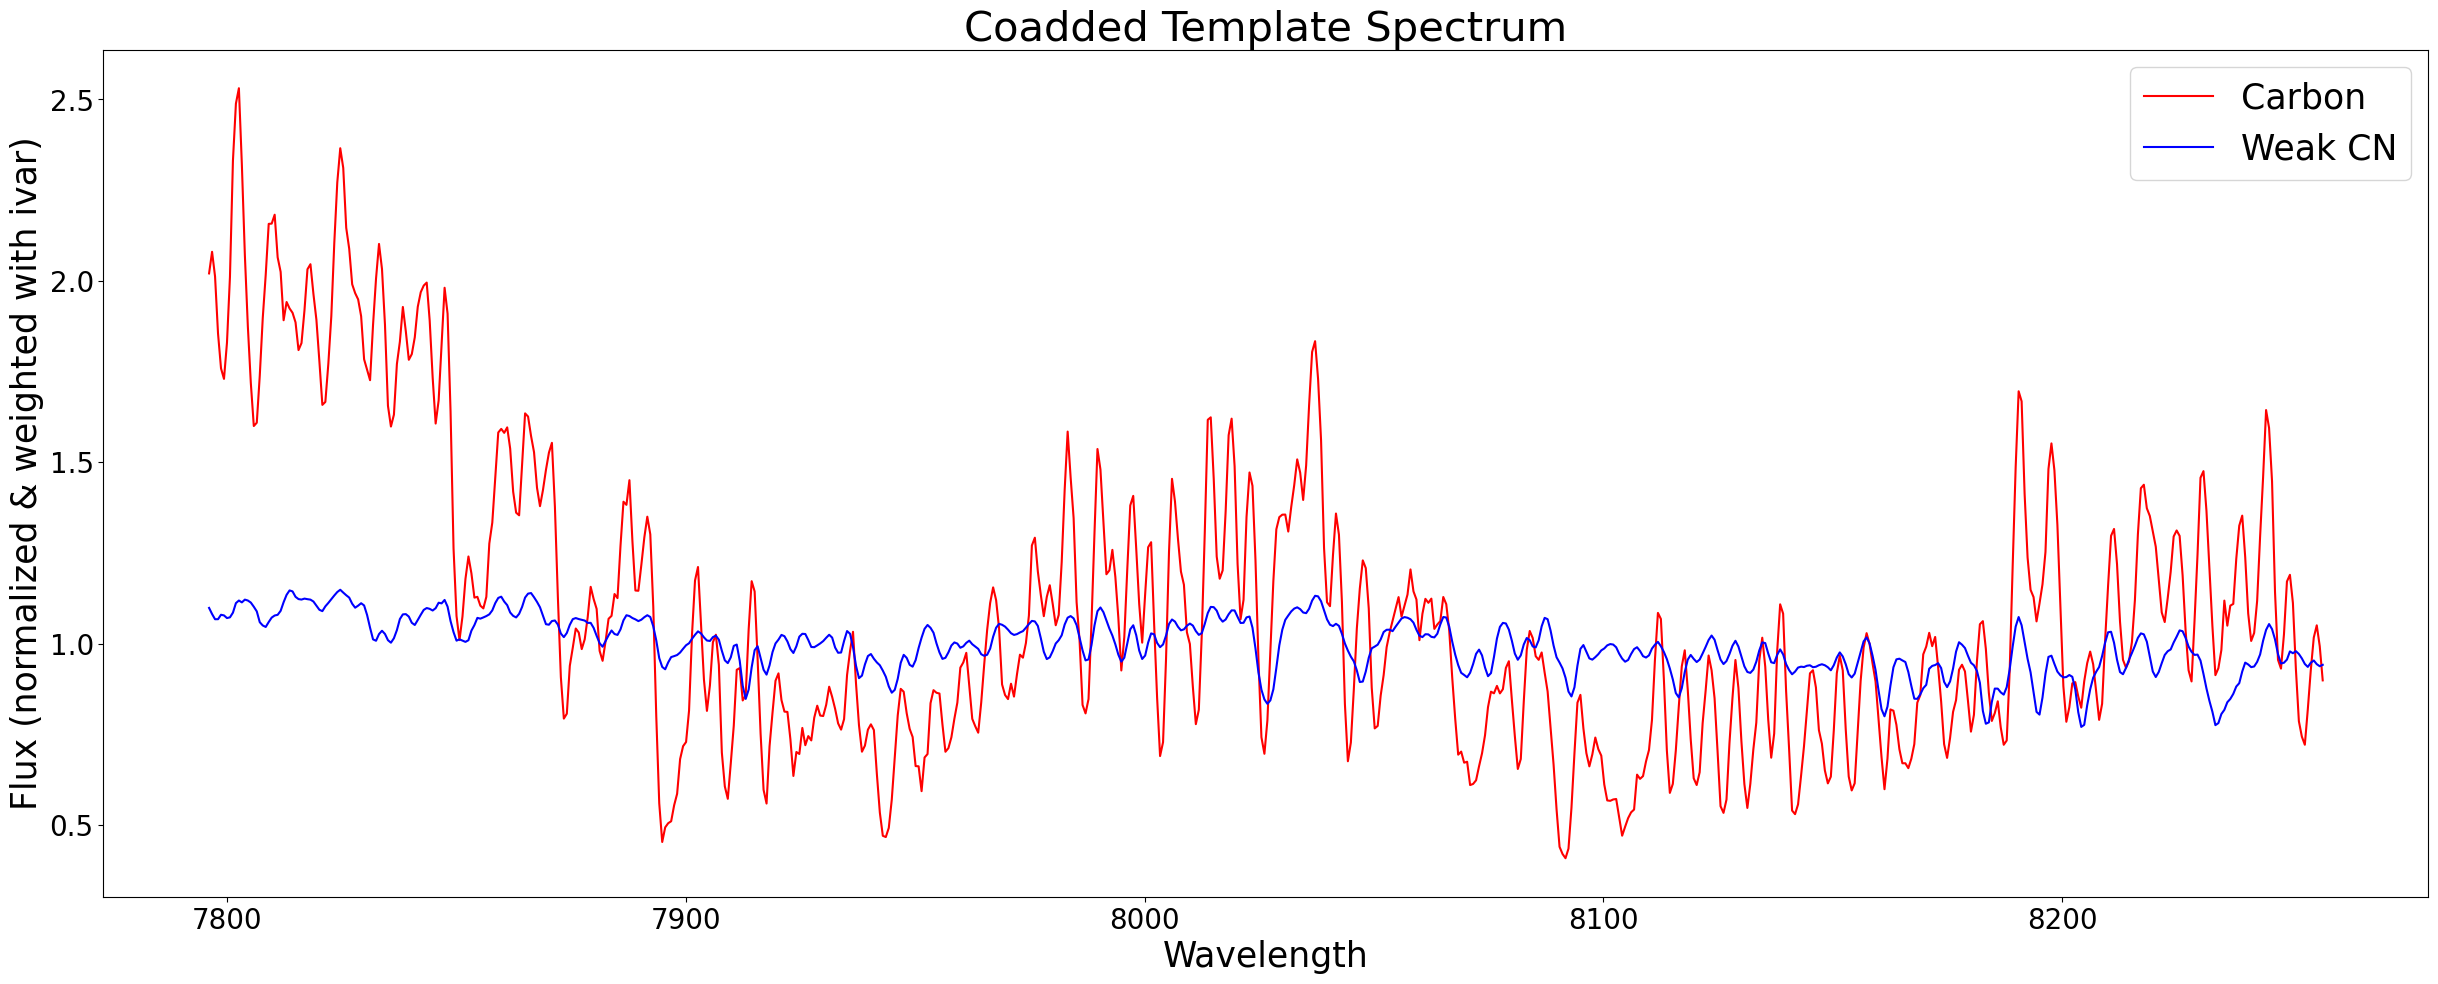

In [33]:
plt.rcParams['figure.figsize'] = 30,11
plt.plot(Ctemplate_wv, Ctemplate, c='red', label='Carbon')
plt.plot(Wtemplate_wv, Wtemplate, c='blue', label='Weak CN')
plt.title("Coadded Template Spectrum", fontsize = 30)
plt.ylabel("Flux (normalized & weighted with ivar)", fontsize = 25)
plt.xlabel("Wavelength", fontsize = 25)
plt.legend(fontsize=25)
plt.tick_params(axis='both', which='both', labelsize=20)
#plt.ylim(0.7,1.3)
plt.show()

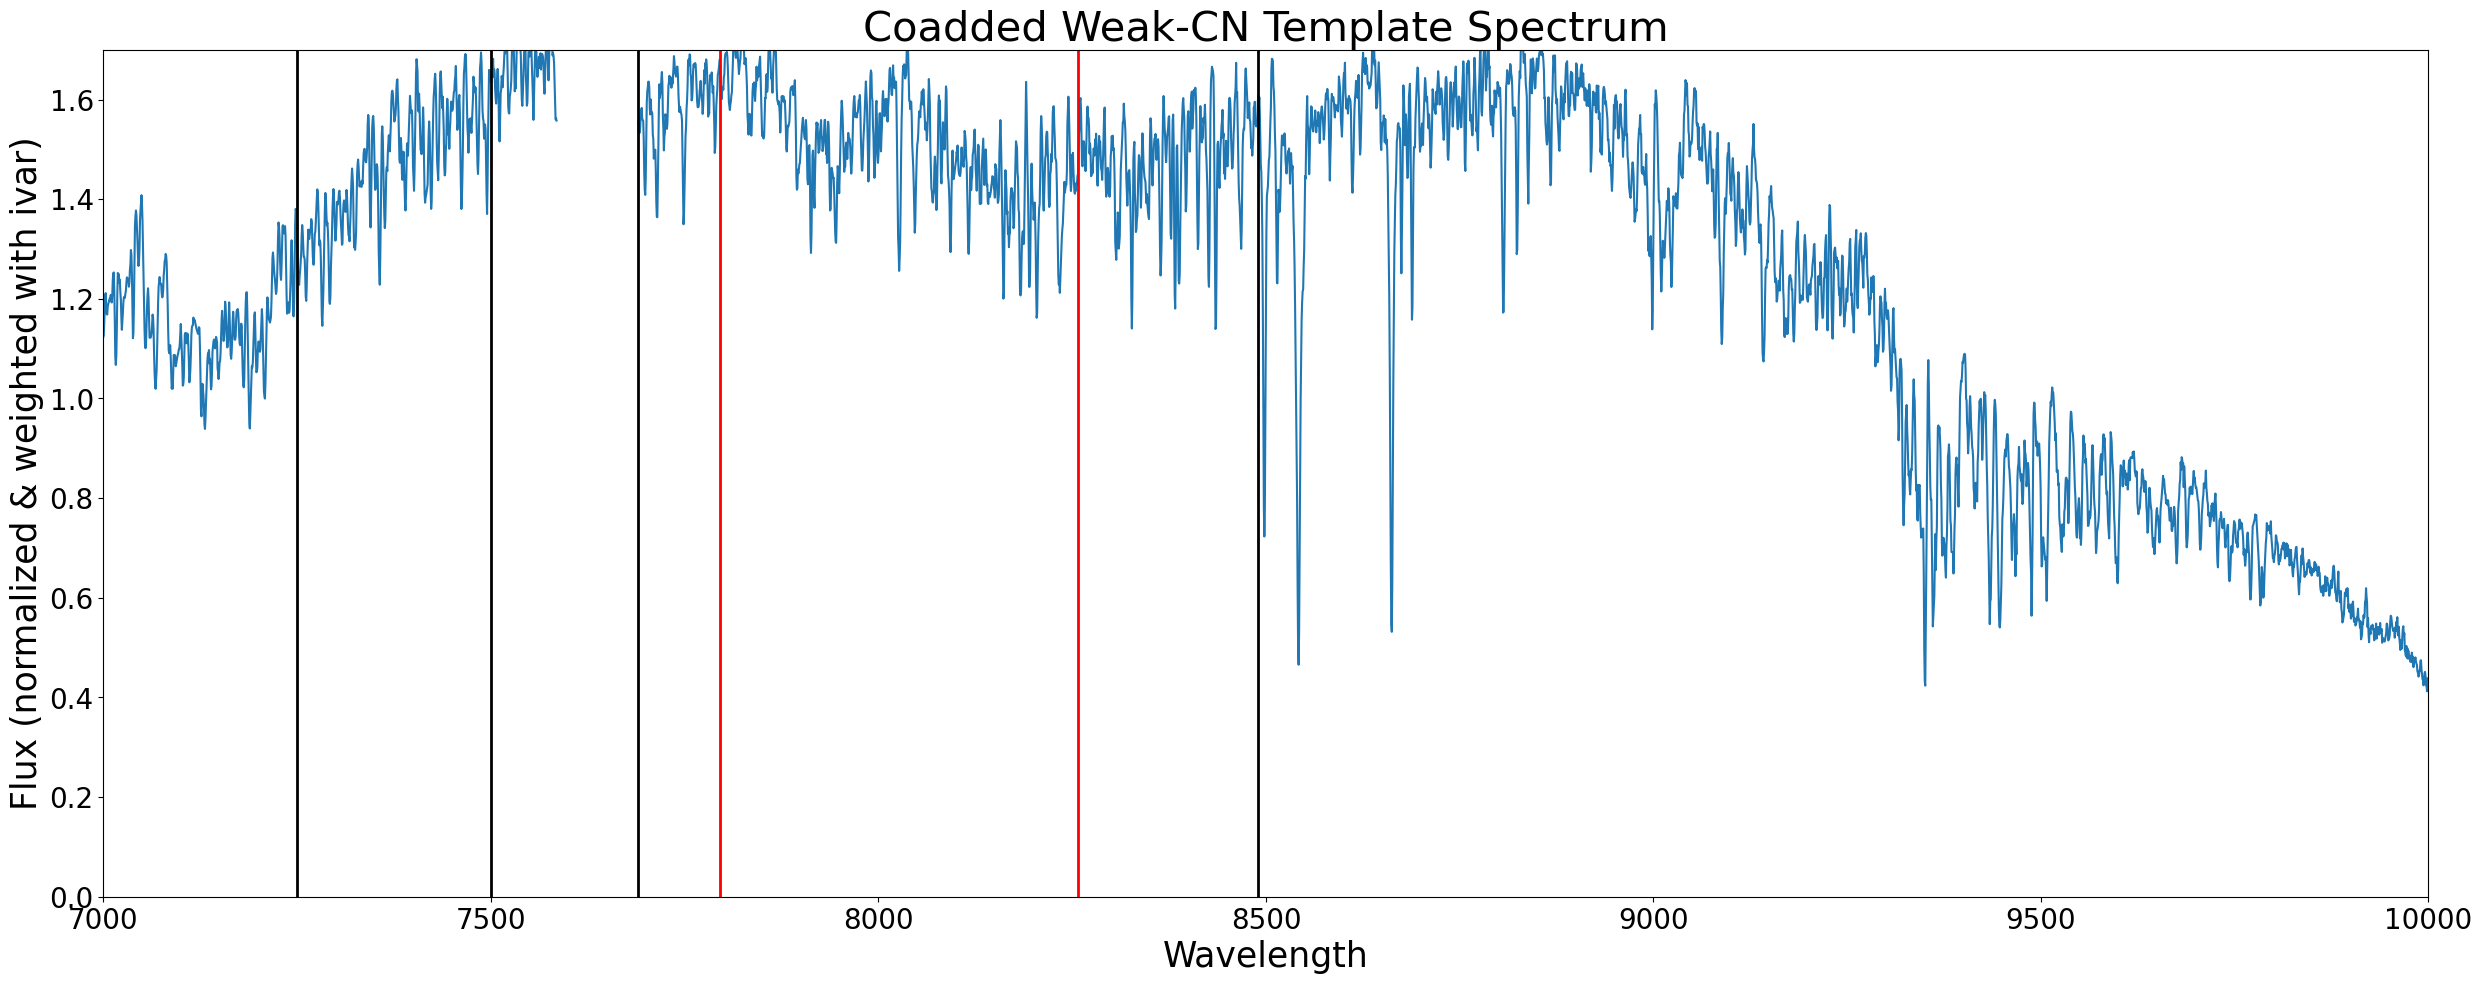

In [34]:
x = Wtemplate_wv_full
y = Wtemplate_full
plt.rcParams['figure.figsize'] = 30,11
plt.plot(x, y)
plt.title("Coadded Weak-CN Template Spectrum", size = 30)
plt.ylabel("Flux (normalized & weighted with ivar)", size = 25)
plt.xlabel("Wavelength", size = 25)
plt.tick_params(axis='both', which='both', labelsize=20)
plt.axvline(7796, c='r', linewidth=2)
plt.axvline(8257.5, c='r', linewidth=2)

plt.axvline(7690, c='k', linewidth=2)

plt.axvline(8490, c='k', linewidth=2)

plt.axvline(7250, c='k', linewidth=2)
plt.axvline(7500, c='k', linewidth=2)
plt.xlim(7000,10000)
plt.ylim(0,1.7)
plt.show()

In [32]:
def get_normed_spectra(starIndices, lower = lowerThresh, upper = upperThresh, nsigma = 3.5):
    #creating lists of normalized spectra and ivars for each star to be coadded
    spectra = []
    ivars = []
    for star in starIndices:
        if lower == lowerThresh and upper == upperThresh:
            #spectra.append(applyGauss(splashSpecs_dict[star],gauss=6).tolist())
            spectra.append(splashSpecs_dict[star].tolist())
            ivars.append(splashIvars_dict[star].tolist())
        else:
            starSpec, starIvar = normspec(star = star, lower = lower, upper = upper)[1:3]
            #starSpec = applyGauss(starSpec,gauss=6)
            spectra.append(starSpec.tolist())
            ivars.append(starIvar.tolist())
    print("Step 1 of 3 complete. Normalized spectra and inverse variances loaded.")

    #takes the original data and replaces with NaN values any data points that are greater than nsigma standard deviations from the median
    #the median is defined as the median flux at each wavelength when the flux values for every spectrum at that wavelength are considered
    spectra_new, ivars_new = sigmaClip(spectra, ivars, nsigma)
    print("Step 2 of 3 complete. Spectral and ivar data clipped to " + str(nsigma) + " sigmas.")
    
    return np.asarray(spectra_new), np.asarray(ivars_new)

In [33]:
keckPhotoOthers = np.arange(0, len(wavln[:,0]),1)
NormFlux_w_full, NormIvar_w_full = get_normed_spectra(keckPhotoOthers)

print(Wtemplate.shape)
print(Ctemplate.shape)
print(NormFlux_w_full.shape)

Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
(710,)
(710,)
(2673, 710)


In [34]:
def getScore(templateSpec, scienceSpec, ivars):
    '''
    templateSpec: a Numpy array containing the flux values of the coadded template spectrum
    scienceSpec: a Numpy array containing the flux values at each wavelength of the normalized spectrum for a specific star
    ivars: a Numpy array containing the normalized ivar values at each wavelength of the spectrum for a specific star
    
    Returns finalScore, a float representing the similarity between the two spectra. A lower score indicates greater similarity and a higher score indicates lower similarity
    Note that spectra that cannot be normalized will not have a score associated with them. The function returns a NaN as the score for these spectra
    '''
    templateSpec_list = templateSpec.tolist()
    scienceSpec_list = scienceSpec[~np.isnan(scienceSpec)].tolist()
    if scienceSpec_list == []:
        print("ScoreError: Because this spectrum cannot be normalized, its score cannot be found.")
        return np.nan
    else:
        summedScore = 0
        for wv in range(len(templateSpec_list)):
            score = ((scienceSpec[wv] - templateSpec[wv])**2) * ivars[wv]
            if not np.isnan(score):
                summedScore += score
        summedIvars = 0
        for ivar in ivars:
            if not np.isnan(ivar):
                summedIvars += ivar
        finalScore = (summedScore/summedIvars)**0.5
        return finalScore

#Rachel- renamed seeModTemplate2 to seeModWtemplate2

#Antara - rewrote this section for spectra that are only tilted and not scaled
#made c=0 everywhere so that spectrum+c/1+c makes no change in spectrum scaling
#also entirely rewrote getRanger, and made some other less extreme changes to the other functions


#defines an important variable that will be used for finding the slopes of spectra
#the slope will not be calculated based on random points, but on the median point in a small "window" at either end of the spectrum
slopeWindow = 25

#defines a function that calculates the slope of a spectrum's wavelength vs flux graph on a certain interval
def getSlope2(spectrum, lower = lowerThresh, upper = upperThresh):
    '''
    spectrum: a list containing the sliced, normalized flux values of the spectrum to be analyzed
    lower: the lower boundary of the range the spectrum will be normalized on, in terms of wavelength index in data["LBIN"]
    upper: the upper boundary of the range the spectrum will be normalized on, in terms of wavelength index in data["LBIN"]
    
    lower and upper will default to the previously defined lowerThresh and upperThresh values, respectively
    
    Returns slope, a numerical value representing the slope of the spectrum on the wavelength range lower to upper
    '''
    lowerInt, upperInt, = spectrum[:slopeWindow], spectrum[-slopeWindow:]
    lowerMedian = np.nanmedian(lowerInt)
    upperMedian = np.nanmedian(upperInt)
    diff = (wavln[0,upper] - wavln[0,lower])
    slope = (upperMedian - lowerMedian)/diff
    return slope

#defines a function that modifies the slope of a spectrum by distorting the graph
def getTiltedSpec2(spectrum, slope, lower = lowerThresh, upper = upperThresh):
    '''
    spectrum: a Numpy array containing the flux values of a (likely normalized) star spectrum to be modified
    slope: a numerical value (most often a float) containing the slope to be applied to the spectrum
    lower: the index of the lower boundary of spectrum in data["LBIN"]
    upper: the index of the upper boundary of spectrum in data["LBIN"]
    
    Note that lower and upper will default to the predefined lowerThresh and upperThresh, respectively
    
    Returns titled, a Numpy array containing the flux values of the adjusted star spectrum
    '''
    
    deltaLam = wavln[0, lower:upper] - wavln[0,lower] #note that the used of data["LBIN"][0] is arbitrary because all spectra have the same LBIN data values
    tilted = slope*deltaLam + spectrum #creating a copy of the spectrum with the new slope
    tilted = tilted/np.nanmedian(tilted) #normalizes the spectrum again
    return tilted

#defines a function that scales a spectrum by either enhancing or reducing spectral features
def getScaledSpec2(spectrum, c):
    '''
    spectrum: a Numpy array containing the flux values of a (likely normalized) star spectrum to be scaled
    c: a numerical value representing the scale factor by which the spectrum will be modified
    
    Returns scaledFlux, a Numpy array containing the flux values of the adjusted star spectrum
    '''
    if c == -1: #accounts for potential divide by zero errors in scaling function
        raise ZeroDivisionError("c cannot be -1 due to the structure of the scaling formula.")
    scaledFlux = (spectrum + c)/(1+c)
    return scaledFlux


#defines a helper function for findOptimalC that produces a list of all the c-values to be tested
def getRanger2(start, stop, step, zoomStart = None, zoomStop = None, zoomStep = None):
    '''
    start: a numerical value representing the lowest value of c you want to test
    stop: a numerical value representing the highest value of c you want to test
    step: a numerical value representing the increment at which you want to create new values of c between start and stop
    zoomStart: a numerical value representing the lowest value of c you want to test with a finer step size
    zoomStop: a numerical value representing the highest value of c you want to test with a finer step size
    zoomStep: a numerical value representing the finer step size to be applied between zoomStop and zoomStart
    
    Note that zoomStart, zoomStop, and zoomStep will all default to None.
    
    Returns rangeList, a list of the scale-factor (c) values to be iterated over for a star that is undergoing the template-matching process
    '''
    rangeList = []
    c = 0
    rangeList.append(c)
    return rangeList

#defines a function that sorts through the c-values produced by getRanger and returns the c-value and s-value that result in the lowest score
def findWOptimalC2(star, template = Wtemplate_full, lower = lowerThresh, upper = upperThresh, lowC = -15, highC = 60, step = 0.5, zoomStart = None, zoomStop = None, zoomStep = None, trackC = False, gauss = False, nsigma = 10):
    '''
    Note that default argument values have been denoted with () in the descriptions below
    
    star: the index of the star for which the template is to be modified to fit and the score is to be calculated
    template: (Ctemplate_full) the template spectrum that will be used to compare the spectrum of star to
    lower: (lowerThresh) the lower boundary for the spectra of star and template to be normalized on/analyzed on
    upper: (upperThresh) the upper boundary for the spectra of star and template to be normalized on/analyzed on
    lowC: (-15) the lower boundary for the range of c-values to be tested
    highC: (60) the upper boundary for the range of c-values to be tested
    step: (0.5) the increment by which c-values between lowC and highC are tested
    zoomStart: (None) the lower boundary for a range of c-values to be tested with a finer increment size
    zoomStop: (None) the upper boundary for a range of c-values to be tested with a finer increment size
    zoomStep: (None) the finer increment size by which c-values between zoomStart and zoomStop are tested
    trackC: (False) a Boolean value that, if True, will produce a graph of c-values and their corresponding scores as the function steps through the c-range; if False, the graph will not be produced
    gauss: (False) a Boolean value that, if True, will apply a Gaussian smoothing kernel to both the template and science spectra before optimal C is found
    nsigma: (10) a numerical value representing the width of the Gaussian kernel that will be used if gauss is True
    
    Returns bestC, the scale factor that yielded the lowest score
    Also returns bestS, the slope that yielded the lowest score (note that this is the version of the slope that has been changed according to the scaled spectrum)
    Also returns bestScore, the "lowest score" referred to above
    '''
    if not normspec(star = star, lower = lower, upper = upper)[3]:
        print("ScoreError: Because this spectrum cannot be normalized, its score cannot be found.")
        return np.nan, np.nan, np.nan
    bestScore = None
    bestC, bestS = 0, 0
    c_coords, sc_coords = [], []
    clipTemplate = template[lower:upper]
    starFlux, starIvar = normspec(star = star, lower = lower, upper = upper)[1:3]
    
    while all(np.isnan(starFlux[:slopeWindow])) or all(starFlux[:slopeWindow] == 0):
        starFlux, starIvar, clipTemplate = starFlux[slopeWindow:], starIvar[slopeWindow:], clipTemplate[slopeWindow:]
        lower += slopeWindow
    while all(np.isnan(starFlux[-slopeWindow:])) or all(starFlux[-slopeWindow:] == 0):
        starFlux, starIvar, clipTemplate = starFlux[:-slopeWindow], starIvar[:-slopeWindow], clipTemplate[:-slopeWindow]
        upper -= slopeWindow
    slope = getSlope2(starFlux, lower, upper)
    for c in getRanger2(lowC, highC, step, zoomStart, zoomStop, zoomStep):
        if c == -1:
            continue
        scaledFlux = getScaledSpec2(clipTemplate, c)
        s = slope - getSlope2(scaledFlux, lower, upper)
        tiltedFlux = getTiltedSpec2(scaledFlux, s, lower, upper)
        testScore = getScore(tiltedFlux, starFlux, starIvar)
        if trackC:
            c_coords.append(c)
            sc_coords.append(testScore)
        if bestScore == None or testScore < bestScore:
            bestC, bestS = c, s
            bestScore = testScore

    return bestC, bestS, bestScore

def findCOptimalC2(star, template = Ctemplate_full, lower = lowerThresh, upper = upperThresh, lowC = -15, highC = 60, step = 0.5, zoomStart = None, zoomStop = None, zoomStep = None, trackC = False, gauss = False, nsigma = 10):
    '''
    Note that default argument values have been denoted with () in the descriptions below
    
    star: the index of the star for which the template is to be modified to fit and the score is to be calculated
    template: (Ctemplate_full) the template spectrum that will be used to compare the spectrum of star to
    lower: (lowerThresh) the lower boundary for the spectra of star and template to be normalized on/analyzed on
    upper: (upperThresh) the upper boundary for the spectra of star and template to be normalized on/analyzed on
    lowC: (-15) the lower boundary for the range of c-values to be tested
    highC: (60) the upper boundary for the range of c-values to be tested
    step: (0.5) the increment by which c-values between lowC and highC are tested
    zoomStart: (None) the lower boundary for a range of c-values to be tested with a finer increment size
    zoomStop: (None) the upper boundary for a range of c-values to be tested with a finer increment size
    zoomStep: (None) the finer increment size by which c-values between zoomStart and zoomStop are tested
    trackC: (False) a Boolean value that, if True, will produce a graph of c-values and their corresponding scores as the function steps through the c-range; if False, the graph will not be produced
    gauss: (False) a Boolean value that, if True, will apply a Gaussian smoothing kernel to both the template and science spectra before optimal C is found
    nsigma: (10) a numerical value representing the width of the Gaussian kernel that will be used if gauss is True
    
    Returns bestC, the scale factor that yielded the lowest score
    Also returns bestS, the slope that yielded the lowest score (note that this is the version of the slope that has been changed according to the scaled spectrum)
    Also returns bestScore, the "lowest score" referred to above
    '''
    if not normspec(star = star, lower = lower, upper = upper)[3]:
        print("ScoreError: Because this spectrum cannot be normalized, its score cannot be found.")
        return np.nan, np.nan, np.nan
    bestScore = None
    bestC, bestS = 0, 0
    c_coords, sc_coords = [], []
    clipTemplate = template[lower:upper]
    starFlux, starIvar = normspec(star = star, lower = lower, upper = upper)[1:3]

    while all(np.isnan(starFlux[:slopeWindow])) or all(starFlux[:slopeWindow] == 0):
        starFlux, starIvar, clipTemplate = starFlux[slopeWindow:], starIvar[slopeWindow:], clipTemplate[slopeWindow:]
        lower += slopeWindow
    while all(np.isnan(starFlux[-slopeWindow:])) or all(starFlux[-slopeWindow:] == 0):
        starFlux, starIvar, clipTemplate = starFlux[:-slopeWindow], starIvar[:-slopeWindow], clipTemplate[:-slopeWindow]
        upper -= slopeWindow
    slope = getSlope2(starFlux, lower, upper)
    for c in getRanger2(lowC, highC, step, zoomStart, zoomStop, zoomStep):
        if c == -1:
            continue
        scaledFlux = getScaledSpec2(clipTemplate, c)
        s = slope - getSlope2(scaledFlux, lower, upper)
        tiltedFlux = getTiltedSpec2(scaledFlux, s, lower, upper)
        testScore = getScore(tiltedFlux, starFlux, starIvar)
        if trackC:
            c_coords.append(c)
            sc_coords.append(testScore)
        if bestScore == None or testScore < bestScore:
            bestC, bestS = c, s
            bestScore = testScore

    return bestC, bestS, bestScore

In [35]:
chi_new_WCN = []
chi_new_C = []
for star in tqdm(range(0, len(wavln[:,0]))):
    c, s, sc = findCOptimalC2(star)
    chi_new_C.append(sc)
    
    c, s, sc = findWOptimalC2(star)
    chi_new_WCN.append(sc)

 55%|█████████████████████▎                 | 1465/2673 [00:42<00:33, 36.05it/s]

NormalizationError: The spectrum for star 1459 contains only NaN values on the specified range. It cannot be normalized.
ScoreError: Because this spectrum cannot be normalized, its score cannot be found.
NormalizationError: The spectrum for star 1459 contains only NaN values on the specified range. It cannot be normalized.
ScoreError: Because this spectrum cannot be normalized, its score cannot be found.


 85%|█████████████████████████████████      | 2266/2673 [01:06<00:11, 35.67it/s]

NormalizationError: The spectrum for star 2261 contains only NaN values on the specified range. It cannot be normalized.
ScoreError: Because this spectrum cannot be normalized, its score cannot be found.
NormalizationError: The spectrum for star 2261 contains only NaN values on the specified range. It cannot be normalized.
ScoreError: Because this spectrum cannot be normalized, its score cannot be found.


100%|███████████████████████████████████████| 2673/2673 [01:18<00:00, 34.07it/s]


In [36]:
chi_squared_list_C = np.asarray(chi_new_C)
chi_squared_list_WCN = np.asarray(chi_new_WCN)
print(chi_squared_list_C.shape)

(2673,)


In [109]:
np.save("chi_squared_list_WCN.npy", chi_squared_list_WCN)
np.save("chi_squared_list_C.npy", chi_squared_list_C)

(-0.1, 1.3)

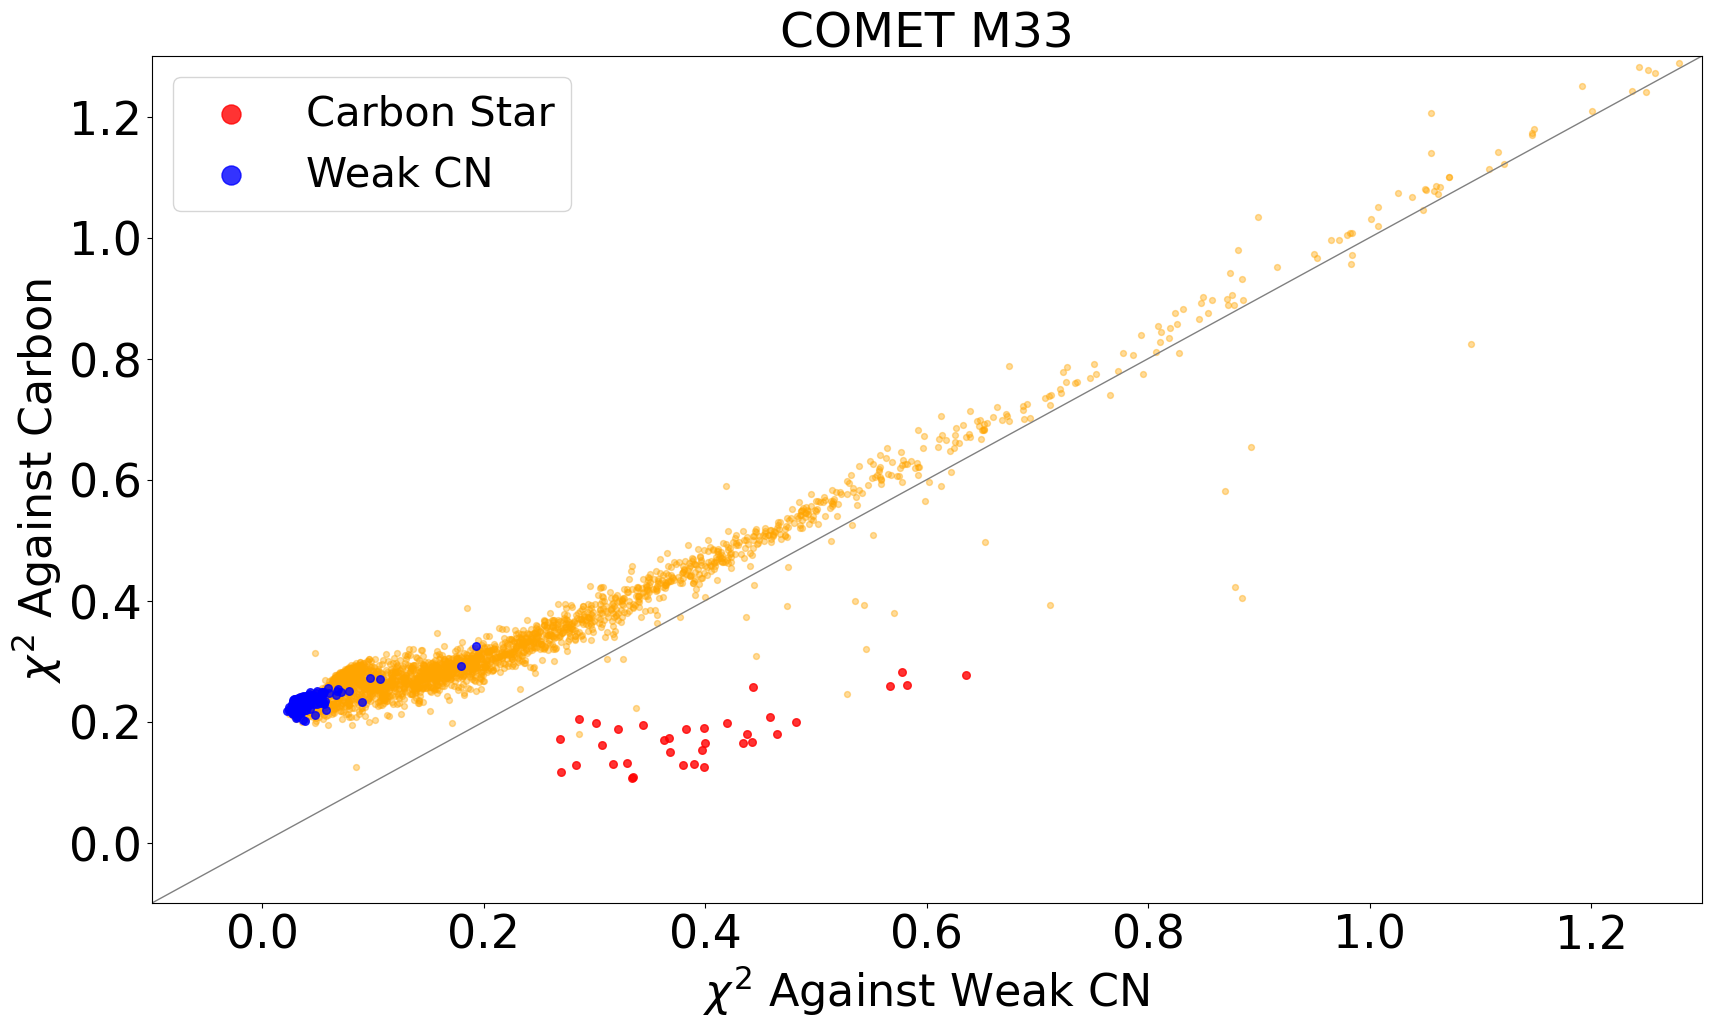

In [37]:
index = np.arange(0, len(chi_squared_list_C), 1)
delete2 = np.append(allcarbon, Wnm)
index = np.delete(index, delete2)
plt.rcParams['figure.figsize'] = 20,11
plt.scatter(chi_squared_list_WCN[index],chi_squared_list_C[index], alpha=0.4, c='orange', s=18)
plt.scatter(chi_squared_list_WCN[allcarbon],chi_squared_list_C[allcarbon], alpha=0.8, c='red', label='Carbon Star', s=30)
plt.scatter(chi_squared_list_WCN[Wnm],chi_squared_list_C[Wnm], alpha=0.8, c='blue', label='Weak CN', s=30)
plt.legend(fontsize=30,markerscale=2.5)

x = [-300,300]
plt.plot(x,x,c='grey', lw=1)
plt.ylabel(r'$\chi^2$ Against Carbon', fontsize=32)
plt.xlabel(r'$\chi^2$ Against Weak CN', fontsize=32)
plt.title('COMET M33', fontsize=35)
plt.tick_params(axis='both', which='both', labelsize=33)
plt.xlim(-0.1,1.3)
plt.ylim(-0.1,1.3)

#plt.axvline(0.0)
#plt.axhline(0.2)

In [38]:
import math  
from scipy.spatial.distance import cdist

def calculate_s(dist):
    p_max = 100
    p_min = 10

    #free parameter D_0 can be used to control the distribution of point sizes
    D_0 = 0.075

    '''
    D is the distance from the comet head
    A small value of D_0 (say 0.5 or less) will result in
    only a few large points and most of the points will be small. 
    A large value of D_0 (say 5) will result in most points being large.
    '''

    w_all = []

    for D in np.nditer(dist):
        w_loop = (p_max - p_min)* math.exp(- D/D_0) + p_min
        w_all.append(w_loop)
        
    return np.asarray(w_all)

def calculate_w(dist):

    D_0 = 1

    weight_all = []

    for D in np.nditer(dist):
        weight1 = math.exp(-1*D/D_0)
        weight_all.append(weight1)
    
    return np.asarray(weight_all)

def get_coadd_params(x_ref, y_ref, full = True):
    index = np.arange(0, len(chi_squared_list_C), 1)
    if full:
        ichoose0 = np.delete(index, allcarbon)
        ichoose3 = np.where((chi_squared_list_WCN[ichoose0] < chi_squared_list_C[ichoose0]))[0]
        coadd_idx = ichoose0[ichoose3]
    
    else:
        ichoose0 = np.delete(index, allcarbon)
        ichoose1 = np.where((f814w[ichoose0]<20.9) & (chi_squared_list_WCN[ichoose0]>=0.0))[0]
        coadd_idx = ichoose0[ichoose1]
        ichoose2 = np.where((chi_squared_list_WCN[coadd_idx] < chi_squared_list_C[coadd_idx]))[0]
        coadd_idx = coadd_idx[ichoose2]
    
    index_all = np.arange(0, len(chi_squared_list_WCN), 1)
    index_all = index_all[coadd_idx]
    
    #create arrays for the comet plot x,y values
    all_coord = np.vstack((chi_squared_list_WCN[coadd_idx], chi_squared_list_C[coadd_idx])).T
    
    xc = np.array(x_ref)
    yc =np.array(y_ref) 
    reference_coord = np.vstack((xc,yc)).T
    
    #calculate distances between reference point and coordinates of stars
    all_dist = cdist(reference_coord, all_coord)
    w_all = calculate_w(all_dist)
    s_all = calculate_s(all_dist)
    return index_all, w_all, s_all

In [39]:
print(len(chi_squared_list_WCN))

2673


In [40]:
index_all, weight_all, size_all = get_coadd_params(0.0, 0.2, full = True)

print(len(weight_all))
print(len(index_all))

bin1 = np.where((weight_all<0.8) )[0]
idx1 = index_all[bin1]

bin2 = np.where((0.8<weight_all)&(weight_all<0.9))[0]
idx2 = index_all[bin2]

bin3 = np.where((0.9<weight_all)&(weight_all<0.95))[0]
idx3 = index_all[bin3]

bin4 = np.where((0.95<weight_all))[0]
idx4 = index_all[bin4]

2583
2583


In [41]:
print(len(allcarbon))

34


In [66]:
print(len(np.where(weight_all>0.9)[0]))

660


In [46]:
print(len(weight_all))
print(len(index_all))
print(len(f475w))
print(len(chi_squared_list_WCN))
print(len(chi_squared_list_C))

2583
2583
2673
2673
2673


In [49]:
print(np.asarray(f814w))

[19.99166679 19.6590004  20.12633324 ... 18.29733467 18.17000008
 20.14249992]


In [51]:
from astropy.table import QTable

ichoose = np.where(weight_all>0.9)[0]

idx_ichoose = index_all[ichoose]

esther_m31_wcn = QTable()
esther_m31_wcn['ra'] =  np.asarray(ra)[idx_ichoose]
esther_m31_wcn['dec'] = np.asarray(dec)[idx_ichoose]
esther_m31_wcn['f475w'] = np.asarray(f475w)[idx_ichoose]
esther_m31_wcn['f814w'] = np.asarray(f814w)[idx_ichoose]

print(esther_m31_wcn)

        ra                dec               f475w              f814w       
------------------ ------------------ ------------------ ------------------
23.529625350671104  30.59135334813789 20.672666549682617 17.702667236328125
23.581081069199005 30.579820590718708 21.589000701904297 18.812000274658203
23.579022009199008 30.574674150718707 22.221500396728516 19.547500610351562
23.582379589199007 30.581451680718708 21.757999420166016 19.354000091552734
23.589141909199007  30.58976412071871 20.016000747680664 19.520999908447266
23.569992111344764 30.552454923298633 18.708999633789062   18.4064998626709
23.568786371344764 30.555070523298635 21.012500762939453  17.97100067138672
               ...                ...                ...                ...
23.516116600671104  30.60496292813789  22.12566566467285 19.333999633789062
23.474930963411406    30.623301828187  22.01799964904785  18.30866813659668
23.469793953411404    30.638683408187 18.243000030517578 18.239500045776367
23.494338933

In [52]:
esther_m31_wcn.write("M31_PHAT_WCNstars.fits")

In [53]:
print(Wnm)

weakcn_full = np.full(len(chi_squared_list_WCN), False)
weakcn_full[Wnm] = True

[   3   13   27   32   53   69   72   77   79   82   83   88   95  112
  113  115  116  120  122  125  134  281  292  300  302  305  310  311
  319  324  325  327  333  334  338  339  342  346  348  351  359  361
  362  366  367  371  440  472  473  509  511  514  515  517  518  520
  532  534  535  538  539  542  547  551  552  556  557  565  569  574
  579  580  581  583  588  590  594  596  598  603  604  613  634  640
  652  653  683  684  687  695  705  711  716  721  723  726  729  733
  740  755  759  762  764  766  770  778  833  834  836  838  850  855
  892  900  922 1019 1023 1115 1117 1122 1123 1129 1135 1136 1214 1218
 1221 1226 1266 1268 1270 1273 1389 1424 1430 1438 1445 1446 2582 2592]


In [59]:
print(len(index_all))
print(len(weakcn_full))

1734
2673


In [76]:
print(index_all)

weakcn = weakcn_full[index_all]

print(weakcn)
print(len(weakcn))

[   0    1    3 ... 2670 2671 2672]
[False False  True ... False False False]
1734


In [77]:
print(len(np.where(weakcn==True)[0]))

140


(-1.0, 6.0)

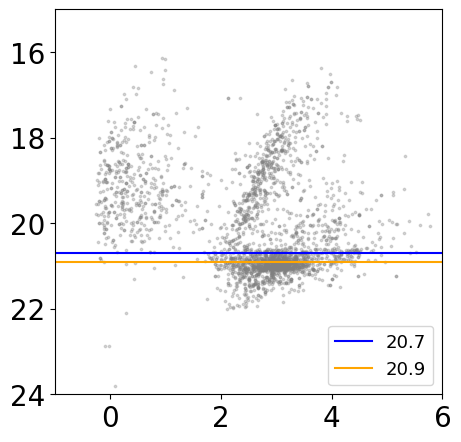

In [79]:
plt.figure(figsize=(5,5))
plt.scatter(f475w-f814w, f814w, s=3, alpha=0.3,c='grey')

plt.axhline(20.7, c='blue', label='20.7')

plt.axhline(20.9, c='orange', label='20.9')

plt.legend(fontsize=13)

plt.ylim(24,15)
plt.xlim(-1,6)

In [69]:
greater_than_09 = np.where((weight_all>0.9))[0]
weakcn2 = weakcn[greater_than_09]

In [70]:
print(len(weakcn2))

660


In [75]:
print(len(np.where(weakcn2==True)[0]))

136


In [54]:
#np.save("M33_weights_all.npy", weight_all)
#np.save("M33_index_all.npy", index_all)
#np.save("M33_sizes_all.npy", size_all)

In [55]:
Bin1_wav, Bin1_temp, Bin1_ivar, Bin1_rms = getTempSpec(idx1, lower = fullSpec_low, upper = fullSpec_high)
Bin2_wav, Bin2_temp, Bin2_ivar, Bin2_rms = getTempSpec(idx2, lower = fullSpec_low, upper = fullSpec_high)
Bin3_wav, Bin3_temp, Bin3_ivar, Bin3_rms = getTempSpec(idx3, lower = fullSpec_low, upper = fullSpec_high)
Bin4_wav, Bin4_temp, Bin4_ivar, Bin4_rms = getTempSpec(idx4, lower = fullSpec_low, upper = fullSpec_high)

Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.
Step 1 of 3 complete. Normalized spectra and inverse variances loaded.
Step 2 of 3 complete. Spectral and ivar data clipped to 3.5 sigmas.
Step 3 of 3 complete. Coaddition of spectra and ivars performed and template created.


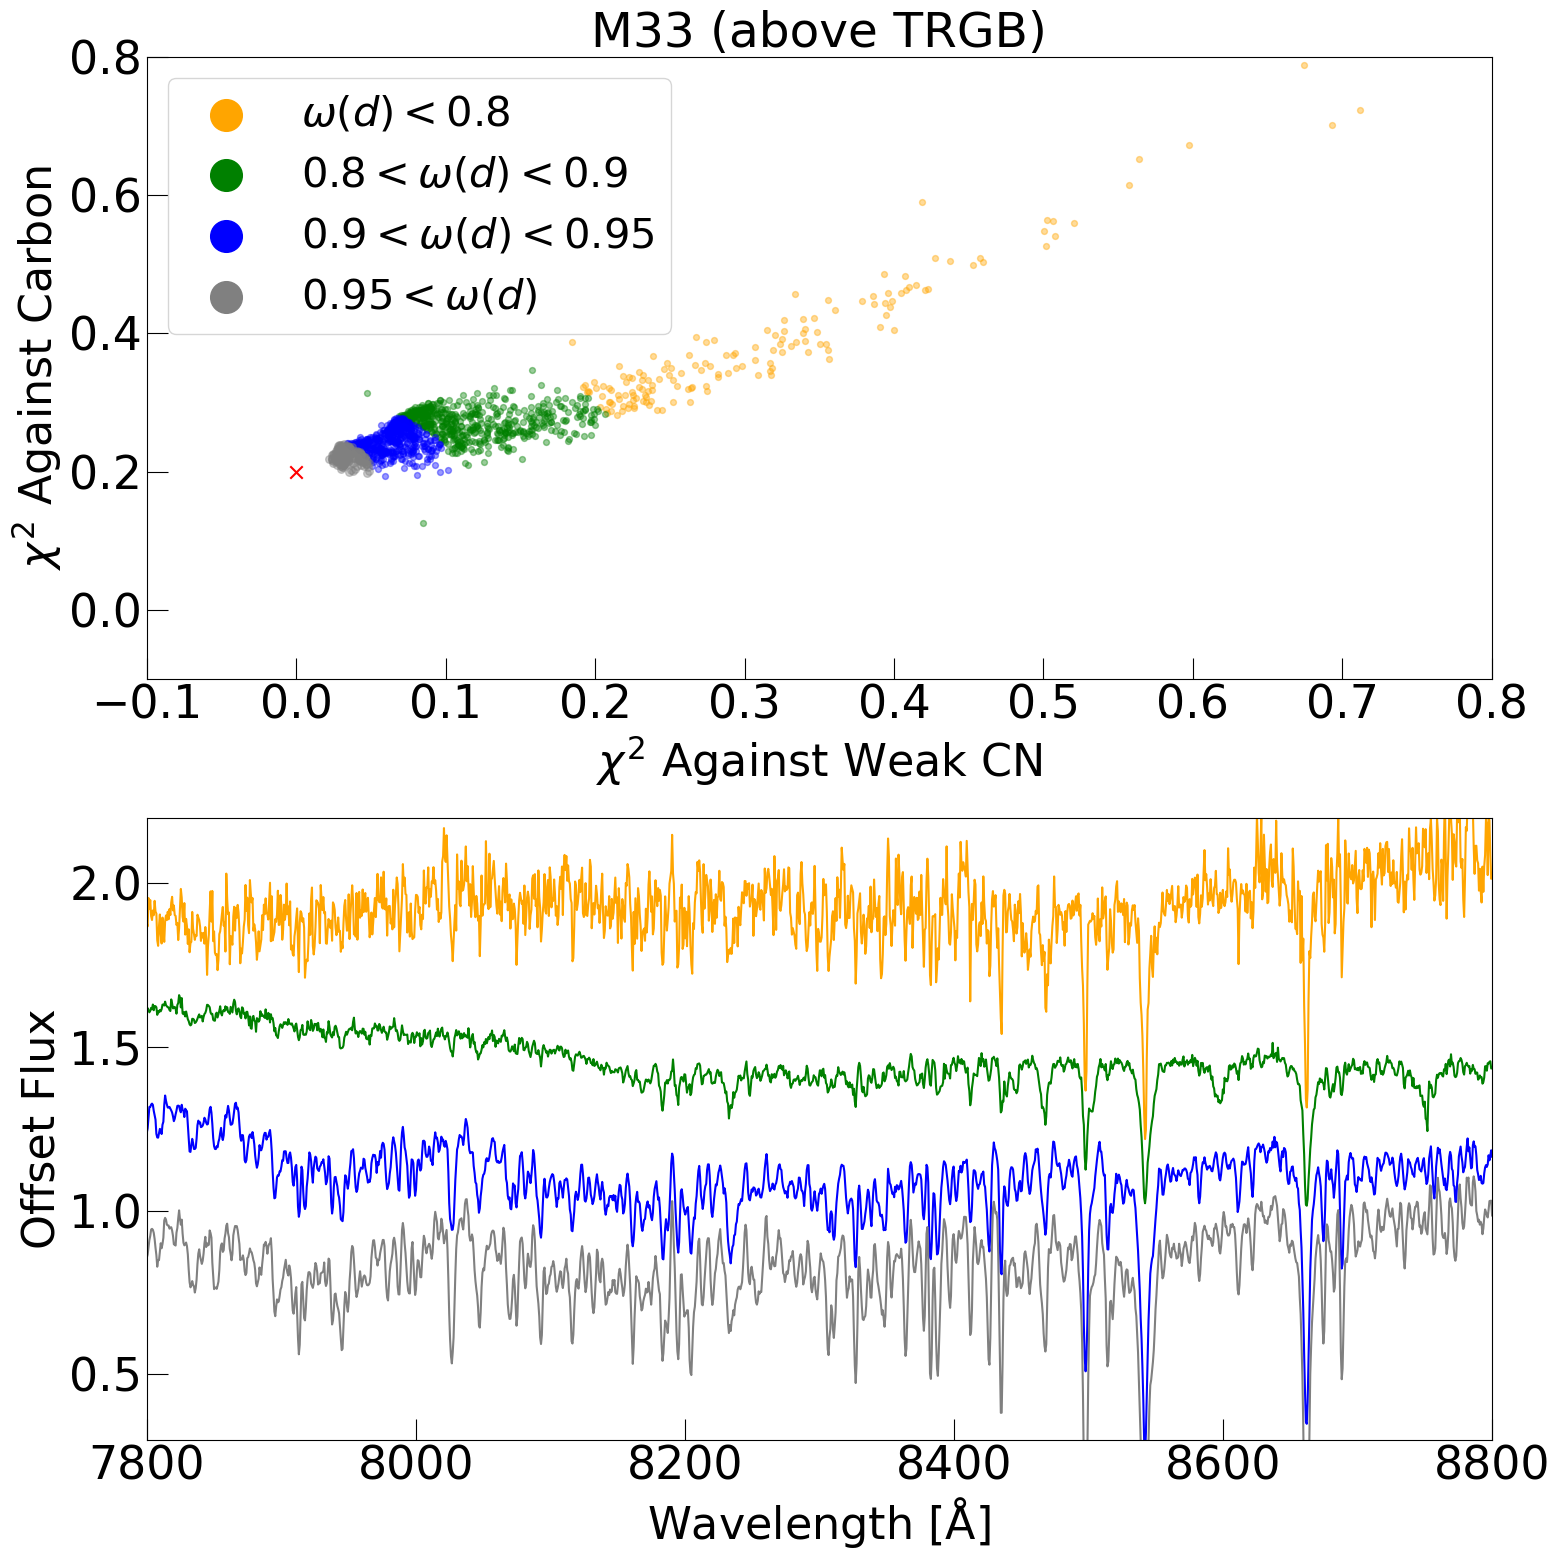

In [56]:
plt.figure(figsize=(16,16))

ax1 = plt.subplot2grid((2,3), (0,0), colspan=3)
ax2 = plt.subplot2grid((2,3), (1,0), colspan=3)
#ax3 = plt.subplot2grid((2,3), (1,2))
######################################################################
ax2.plot(Bin1_wav, Bin1_temp+0.7, c='orange', label=r'$\omega(d)<20$')
ax2.plot(Bin1_wav, Bin2_temp+0.4, c='green', label=r'$20<\omega(d)<40$')
ax2.plot(Bin1_wav, Bin3_temp-0.2, c='blue', label=r'$40<\omega(d)<60$')
ax2.plot(Bin1_wav, Bin4_temp-0.8, c='grey', label=r'$<60\omega(d)$')

#ax2.set_title("Coadd based on COMET distance", size = 30)
ax2.set_ylabel("Offset Flux", size = 32)
ax2.set_xlabel("Wavelength [$\mathrm{\AA}$]", size = 32)
ax2.tick_params(axis='both', which='both',direction='in', labelsize=33, length=15)

#ax2.legend(loc='upper right', fontsize=18)
ax2.set_xlim(7800,8800)
ax2.set_ylim(0.3,2.2)
#######################################################################
x = np.linspace(0,10,1000)


#######################################################################################
ax1.scatter(chi_squared_list_WCN[idx1],chi_squared_list_C[idx1], alpha=0.4, c='orange', s=18, label=r'$\omega(d)<0.8$')
ax1.scatter(chi_squared_list_WCN[idx2],chi_squared_list_C[idx2], alpha=0.4, c='green', s=18, label=r'$0.8<\omega(d)<0.9$')
ax1.scatter(chi_squared_list_WCN[idx3],chi_squared_list_C[idx3], alpha=0.4, c='blue', s=18, label=r'$0.9<\omega(d)<0.95$')
ax1.scatter(chi_squared_list_WCN[idx4],chi_squared_list_C[idx4], alpha=0.4, c='grey', s=30, label=r'$0.95<\omega(d)$')


ax1.scatter(0.0, 0.2, marker="x",color='r',s=80)


ax1.set_ylabel(r'$\chi^2$ Against Carbon', fontsize=32)
ax1.set_xlabel(r'$\chi^2$ Against Weak CN', fontsize=32)
ax1.set_title("M33 (above TRGB)", fontsize=35)
ax1.tick_params(axis='both', which='both',direction='in', labelsize=33, length=15)
ax1.set_xlim(-0.1,0.8)
ax1.set_ylim(-0.1,0.8)

lgnd = ax1.legend(loc='upper left', fontsize=30)
for lh in lgnd.legendHandles:
    lh.set_alpha(1)
    lh._sizes = [520]

plt.tight_layout()

In [54]:
coadd_full = np.empty((5, 10770))
coadd_full[0,:] = Bin1_wav
coadd_full[1,:] = Bin1_temp
coadd_full[2,:] = Bin2_temp
coadd_full[3,:] = Bin3_temp
coadd_full[4,:] = Bin4_temp

In [55]:
#np.save("M33_coaddFull_table.npy", coadd_full)
np.save("M33_coaddTRGB_table.npy", coadd_full)

In [56]:
idx_master = np.full(len(chi_squared_list_WCN), 0)
idx_master[idx1] = 0.8
idx_master[idx2] = 0.9
idx_master[idx3] = 0.95
idx_master[idx4] = 1.



#np.save("M33_coaddFull_indices.npy", idx_master)
np.save("M33_coaddTRGB_indices.npy", idx_master)

In [ ]:
'''def movingMedian (x, t, window):
    medians = []
    times = []
    i = 0
    while(i < len(x)):
        if(i <= int(window/2) or i >= len (x) - int(window/2)):
            medians.append(x[i])
            times.append(t[i])
        else:
            med = np.median(x[i:i+window])
            medians.append(med)
            times.append(np.median(t[i:i+window]))
        i += 1
    return np.asarray(medians), np.asarray(times)

Bin1_rms2, Bin1_wav2 = movingMedian(Bin1_rms, Bin1_wav, 20)
Bin2_rms2, Bin2_wav2 = movingMedian(Bin2_rms, Bin2_wav, 20)
Bin3_rms2, Bin3_wav2 = movingMedian(Bin3_rms, Bin3_wav, 20)
Bin4_rms2, Bin4_wav2 = movingMedian(Bin4_rms, Bin4_wav, 20)'''

NameError: name 'Bin1_wav' is not defined

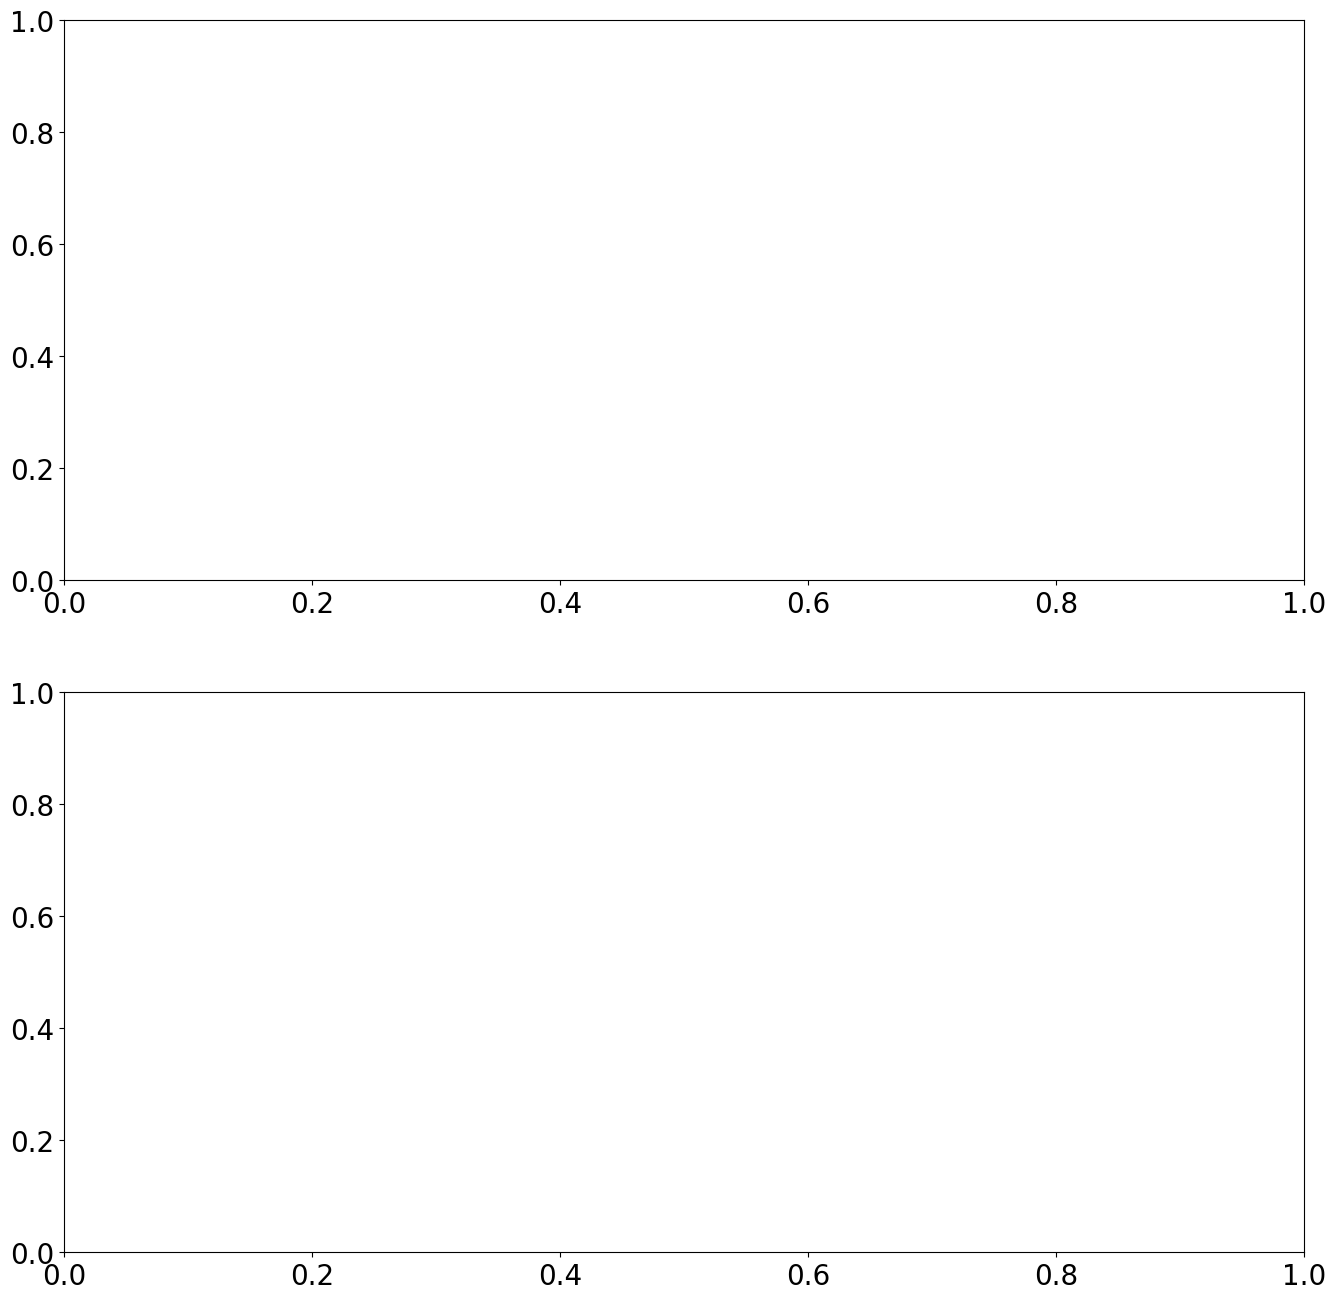

In [44]:
plt.figure(figsize=(16,16))

ax1 = plt.subplot2grid((2,3), (0,0), colspan=3)
ax2 = plt.subplot2grid((2,3), (1,0), colspan=3)
#ax3 = plt.subplot2grid((2,3), (1,2))
######################################################################
ax2.plot(Bin1_wav, Bin1_temp+0.7, c='orange', label=r'$\omega(d)<20$')
ax2.plot(Bin2_wav, Bin2_temp+0.4, c='green', label=r'$20<\omega(d)<40$')
ax2.plot(Bin3_wav, Bin3_temp-0.2, c='blue', label=r'$40<\omega(d)<60$')
ax2.plot(Bin4_wav, Bin4_temp-0.8, c='grey', label=r'$<60\omega(d)$')

#ax2.set_title("Coadd based on COMET distance", size = 30)
ax2.set_ylabel("Offset Flux", size = 30)
ax2.set_xlabel("Wavelength [Angstroms]", size = 30)
ax2.tick_params(axis='both', which='both',direction='in', labelsize=30, length=15)

#ax2.legend(loc='upper right', fontsize=18)
ax2.set_xlim(7800,8800)
ax2.set_ylim(0.3,2.2)
#######################################################################
x = np.linspace(0,10,1000)


#######################################################################################
ax1.scatter(chi_squared_list_WCN[idx1],chi_squared_list_C[idx1], alpha=0.4, c='orange', s=18, label=r'$\omega(d)<0.8$')
ax1.scatter(chi_squared_list_WCN[idx2],chi_squared_list_C[idx2], alpha=0.4, c='green', s=18, label=r'$0.8<\omega(d)<0.9$')
ax1.scatter(chi_squared_list_WCN[idx3],chi_squared_list_C[idx3], alpha=0.4, c='blue', s=18, label=r'$0.9<\omega(d)<0.95$')
ax1.scatter(chi_squared_list_WCN[idx4],chi_squared_list_C[idx4], alpha=0.4, c='grey', s=30, label=r'$0.95<\omega(d)$')


ax1.scatter(0.0, 0.2, marker="x",color='r',s=80)


ax1.set_ylabel(r'$\chi^2$ Against Carbon', fontsize=30)
ax1.set_xlabel(r'$\chi^2$ Against Weak CN', fontsize=30)
ax1.set_title("M33 (above TRGB)", fontsize=35)
ax1.tick_params(axis='both', which='both',direction='in', labelsize=30, length=15)
ax1.set_xlim(-0.1,0.8)
ax1.set_ylim(-0.1,0.8)

lgnd = ax1.legend(loc='upper left', fontsize=30)
for lh in lgnd.legendHandles:
    lh.set_alpha(1)
    lh._sizes = [520]

plt.tight_layout()